# **Análisis Exploratorio de Datos**
## ATUS Anual 2024 - Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas
### Proyecto Final - Almacenes y Minería de Datos

Este notebook presenta el análisis exploratorio del conjunto de datos **ATUS 2024**, publicado por el
Instituto Nacional de Estadística y Geografía (INEGI). Los registros provienen de dependencias de
seguridad pública y vialidad estatales y municipales, así como de agencias del Ministerio Público y
juzgados cívicos en la Ciudad de México.

El dataset contiene **390,627 registros y 45 variables** con cobertura a nivel municipal, y describe
cada accidente a partir de su ubicación geográfica, fecha y hora de ocurrencia, tipo de percance,
vehículos involucrados, causa presunta, características del conductor y número de personas heridas
o fallecidas.

El objetivo de este análisis es comprender la estructura, calidad y distribución de los datos como
paso previo al modelado. Los hallazgos obtenidos aquí informarán las decisiones de preprocesamiento
y la selección de variables para la **clasificación supervisada** (predicción de la severidad del
accidente) y el **agrupamiento no supervisado** (identificación de perfiles de accidentes).

**Fuente:** [INEGI — Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas](https://www.inegi.org.mx/programas/atus/)  
**Archivo utilizado:** `atus_anual_2024.csv`


In [1]:
import pandas as pd

dataset_raw = pd.read_csv("../data/atus_anual_2024.csv")
dataset_raw

,COBERTURA,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1,1,2024,1,2,25,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
1,Municipal,1,1,2024,1,3,40,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
2,Municipal,1,1,2024,1,4,37,1,lunes,Accidente en intersección,...,0,1,0,0,0,0,0,0,No fatal,Cifras Corregidas
3,Municipal,1,1,2024,1,5,0,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
4,Municipal,1,1,2024,1,6,45,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390622,Municipal,32,56,2024,12,5,15,27,Viernes,Accidente en no intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
390623,Municipal,32,56,2024,12,0,38,28,Sabado,Accidente en no intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
390624,Municipal,32,56,2024,12,9,45,30,lunes,Accidente en no intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
390625,Municipal,32,56,2024,12,16,18,30,lunes,Accidente en no intersección,...,0,0,0,0,0,0,0,0,No fatal,Cifras Definitivas


## **1. Tamano y Dimensiones del Dataset**

In [2]:
filas, columnas = dataset_raw.shape
tamano_memoria_mb = dataset_raw.memory_usage(deep=True).sum() / 1024**2

print(f"Cantidad de filas: {filas}")
print(f"Cantidad de columnas: {columnas}")
print(f"Tamano aproximado en memoria: {tamano_memoria_mb:.2f} MB")

Cantidad de filas: 390627
Cantidad de columnas: 45
Tamano aproximado en memoria: 394.80 MB


## 2. Analisis de las variables
Este es un resumen básico de cada columna del dataset. Se nos muestra Nombre de columna, tipo de dato, cantidad de valores no nulos y nulos, y cuantos valores únicos hay por columna / variable.

In [3]:
resumen_columnas = pd.DataFrame({
    "Columna": dataset_raw.columns,
    "Tipo de dato": dataset_raw.dtypes.values,
    "Valores no nulos": dataset_raw.notna().sum().values,
    "Valores nulos": dataset_raw.isna().sum().values,
    "Valores únicos": dataset_raw.nunique().values
})

resumen_columnas

,Columna,Tipo de dato,Valores no nulos,Valores nulos,Valores únicos
0,COBERTURA,str,390627,0,1
1,ID_ENTIDAD,int64,390627,0,32
2,ID_MUNICIPIO,int64,390627,0,570
3,ANIO,int64,390627,0,1
4,MES,int64,390627,0,12
5,ID_HORA,int64,390627,0,24
6,ID_MINUTO,int64,390627,0,60
7,ID_DIA,int64,390627,0,31
8,DIASEMANA,str,390627,0,7
9,URBANA,str,390627,0,3


### Observaciones

- **Sin valores nulos:** El dataset no contiene valores nulos en ninguna de sus columnas. Sin embargo,
  esto no implica ausencia de datos faltantes: como veremos más adelante, algunas columnas utilizan
  códigos especiales (por ejemplo, `0` y `99` en `ID_EDAD`, o `"Certificado cero"` en `TIPACCID`)
  para representar situaciones donde la información no está disponible. Estos casos requieren un
  tratamiento cuidadoso antes del modelado.

- **Variables categóricas:** Columnas como `TIPACCID`, `CAUSAACCI`, `SEXO`, `URBANA`, `SUBURBANA`,
  `CAPAROD`, `ALIENTO`, `CINTURON` y `CLASACC` describen características cualitativas del accidente,
  del conductor y del entorno. Estas variables deberán codificarse antes de ser utilizadas en los
  modelos de aprendizaje automático.

- **Variables numéricas de conteo:** Las columnas relacionadas con vehículos involucrados
  (`AUTOMOVIL`, `MOTOCICLET`, `CAMIONETA`, etc.) y con víctimas (`CONDMUERTO`, `CONDHERIDO`,
  `PASAMUERTO`, etc.) representan cantidades enteras. Su distribución es típicamente muy sesgada
  hacia cero, ya que la mayoría de los accidentes involucran pocos vehículos y víctimas.

- **Columnas sin variación:** `COBERTURA`, `ANIO`, `NEMUERTO` y `NEHERIDO` presentan un único valor
  en todos sus registros. Dado que no permiten distinguir entre accidentes ni aportan capacidad
  predictiva, serán eliminadas durante la etapa de limpieza.

## **3. Diccionario de Datos**

El siguiente diccionario está basado en la documentación oficial incluida en el conjunto de datos
ATUS 2024, disponible en el portal de microdatos del INEGI. Describe cada una de las 45 variables
del dataset: su nombre, descripción, tipo de dato, longitud máxima ( varchar ) y los códigos o valores válidos
según la especificación oficial.

Consultar este diccionario es fundamental para interpretar correctamente los valores del dataset,
ya que varias columnas utilizan códigos numéricos o cadenas específicas con significados que no
son evidentes a simple vista. Por ejemplo, en `ID_EDAD` los valores `0` y `99` no representan
edades reales, y el valor `"Certificado cero"` en múltiples columnas categóricas identifica
registros administrativos sin accidente asociado.

In [4]:
diccionario_datos = pd.read_csv("../data/diccionario_de_datos_atus_anual_2024.csv")

print(f"Cantidad de variables documentadas: {diccionario_datos.shape[0]}")
diccionario_datos

Cantidad de variables documentadas: 45


,COLUMNA,DESCRIPCION,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,COBERTURA,Área geográfica a la que están referidos los i...,varchar,200.0,NaN
1,ID_ENTIDAD,Clave de la entidad federativa según el Catálo...,varchar,2.0,01-32
2,ID_MUNICIPIO,Clave del municipio según el Catálogo de Entid...,varchar,3.0,001-999
3,ANIO,Los cuatro dígitos correspondientes al año en ...,int,NaN,1997-2024
4,MES,Correspondiente al mes de referencia en que oc...,varchar,2.0,01-12
5,ID_HORA,La hora (sin los minutos) en que ocurrió el ac...,int,NaN,0-23
6,ID_MINUTO,"Los minutos en que ocurrió el accidente, con r...",int,NaN,0-59
7,ID_DIA,Número correspondiente al día del mes en que o...,varchar,2.0,0-31
8,DIASEMANA,El día de la semana en que ocurrió el accidente,varchar,20.0,"Lunes-Domingo, Certificado cero, No especificado"
9,URBANA,Es el área habitada o urbanizada que partiendo...,varchar,50.0,"Accidente en intersección, Accidente en no int..."


### Observaciones del diccionario

- **Identificadores geográficos:** `ID_ENTIDAD` e `ID_MUNICIPIO` almacenan claves numéricas del
  catálogo oficial de INEGI, no nombres de lugares. Para identificar correctamente un municipio
  es necesario usar ambas columnas en conjunto, ya que una misma clave de municipio puede
  repetirse en distintas entidades federativas.

- **Códigos especiales en `ID_EDAD`:** El valor `0` indica que el conductor se fugó y el valor
  `99` indica que se desconoce su edad. Ninguno de los dos representa una edad real, por lo que
  tratarlos como valores numéricos ordinales distorsionaría cualquier análisis estadístico y
  afectaría negativamente el desempeño de los modelos. Su tratamiento será una decisión clave
  en la etapa de limpieza.

- **Registros con `Certificado cero`:** Este valor identifica municipios que informaron
  oficialmente, mediante un certificado formal, la ausencia de accidentes viales en su
  jurisdicción. No representa un accidente real ni un dato faltante, sino una declaración
  administrativa verificada.

- **Variables de conteo:** Las columnas de vehículos (`AUTOMOVIL`, `MOTOCICLET`, etc.) y de
  víctimas (`CONDMUERTO`, `CONDHERIDO`, `PASAMUERTO`, etc.) representan cantidades enteras por
  accidente. Un mismo accidente puede involucrar vehículos de distintas categorías, por lo que
  estas columnas no son mutuamente excluyentes y deben interpretarse en conjunto.

## **4. Calidad de los Datos**

Antes de realizar cualquier análisis estadístico o de modelado, es necesario evaluar la calidad
del dataset. En esta sección identificamos situaciones que requieren atención: valores nulos,
filas duplicadas, columnas sin variación y códigos especiales que no representan datos reales.

El propósito de esta sección es exclusivamente diagnóstico. Los datos originales no se modifican
aquí; todas las decisiones de limpieza y sus justificaciones se documentan en la sección 6.

### 4.1 Valores Nulos

Primero verificamos si existen celdas vacías o valores nulos. Este paso permite saber si faltan datos en alguna columna.

In [5]:
valores_nulos = dataset_raw.isnull().sum()

print(f"Total de valores nulos: {valores_nulos.sum()}")
valores_nulos[valores_nulos > 0]

Total de valores nulos: 0


Series([], dtype: int64)

### 4.2 Filas Duplicadas

Contamos las filas que tienen exactamente los mismos valores en todas sus columnas. Dado que el
dataset no incluye un identificador único por accidente, no es posible descartar automáticamente
que dos filas idénticas correspondan a eventos distintos. Por eso, antes de tomar una decisión,
debemos inspeccionar el contenido de los duplicados más adelante en la limpieza de datos.

In [6]:
filas_duplicadas = dataset_raw.duplicated().sum()

print(f"Cantidad de filas duplicadas: {filas_duplicadas}")

Cantidad de filas duplicadas: 871


### 4.3 Columnas sin Variación

También identificamos las columnas que tienen un solo valor único. Estas variables no permiten comparar registros porque su contenido es el mismo en todo el dataset.

In [7]:
cantidad_valores_unicos = dataset_raw.nunique()
columnas_sin_variacion = cantidad_valores_unicos[cantidad_valores_unicos == 1]

columnas_sin_variacion

COBERTURA    1
ANIO         1
NEMUERTO     1
NEHERIDO     1
dtype: int64

### 4.4 Valores Especiales

Identificamos los códigos especiales documentados en el diccionario oficial del INEGI que no
representan datos reales y requieren tratamiento antes del modelado.

- **`Certificado cero`:** Presente en múltiples columnas categóricas. Identifica municipios que
  informaron oficialmente la ausencia de accidentes viales en su jurisdicción. No corresponde
  a ningún percance real y deberá excluirse del análisis.

- **`ID_EDAD = 0`:** Indica que el conductor presunto responsable se fugó de la escena y no fue
  posible registrar sus datos. No representa una edad real.

- **`ID_EDAD = 99`:** Indica que la edad del conductor es desconocida. Tampoco representa una
  edad real.

Aunque el dataset no reporta valores nulos, estos códigos son efectivamente datos faltantes
enmascarados. Su tratamiento se define en la sección 6.

In [8]:
certificados_cero = (dataset_raw["TIPACCID"] == "Certificado cero").sum()
conductores_fugados = (dataset_raw["ID_EDAD"] == 0).sum()
edades_desconocidas = (dataset_raw["ID_EDAD"] == 99).sum()

print(f"Registros con certificado cero: {certificados_cero}")
print(f"Registros con conductor fugado: {conductores_fugados}")
print(f"Registros con edad desconocida: {edades_desconocidas}")

Registros con certificado cero: 15678
Registros con conductor fugado: 50715
Registros con edad desconocida: 61564


### Conclusiones del análisis de calidad

- **Valores nulos:** El dataset no contiene valores nulos en ninguna columna. Sin embargo,
  existen códigos especiales que funcionan como datos faltantes enmascarados y que requieren
  tratamiento explícito antes del modelado.

- **Filas duplicadas:** Se encontraron 871 filas con valores idénticos en todas sus columnas
  (≈0.22% del dataset). La ausencia de un identificador único impide descartarlas
  automáticamente, por lo que su contenido será inspeccionado en la sección de limpieza antes
  de tomar una decisión.

- **Columnas sin variación:** `COBERTURA`, `ANIO`, `NEMUERTO` y `NEHERIDO` presentan un único
  valor en todos sus registros y no aportarán información discriminativa en ninguna etapa del
  análisis.

- **Registros con `Certificado cero`:** Se identificaron 15,678 registros correspondientes a
  municipios que informaron oficialmente la ausencia de accidentes en su jurisdicción. Al no
  representar percances reales, deberán excluirse antes de cualquier análisis o modelado.

- **Códigos especiales en `ID_EDAD`:** Se encontraron 50,715 registros con valor `0` (conductor
  fugado) y 61,564 con valor `99` (edad desconocida). En conjunto, el 28.8% de los registros
  del dataset no tiene una edad válida registrada, lo que representa una limitación importante
  a considerar durante el preprocesamiento.

## **5. Análisis por Columna**

En esta sección se analiza cada variable del dataset de forma individual. Para cada columna se
revisa su significado conforme al diccionario oficial, la distribución de sus valores y las
implicaciones que esto tiene para las etapas de limpieza y modelado.

El análisis se realiza sobre el dataset original sin modificaciones. Para las columnas donde los
registros con `Certificado cero` distorsionan la distribución, se utiliza una variable auxiliar
que los excluye, dejando explícito en cada caso cuándo se aplica este filtro.

### 5.1 COBERTURA

De acuerdo con el diccionario de datos, esta columna indica el área geográfica a la que corresponden los registros. En la sección anterior ya vimos que `COBERTURA` no presenta variación. De todas formas mostramos el conteo de sus valores para que este resultado quede explícito.

In [9]:
analisis_cobertura = dataset_raw["COBERTURA"].value_counts().reset_index()
analisis_cobertura.columns = ["COBERTURA", "Cantidad de registros"]
analisis_cobertura["Porcentaje"] = (
    analisis_cobertura["Cantidad de registros"] / len(dataset_raw) * 100
).round(2)

analisis_cobertura

,COBERTURA,Cantidad de registros,Porcentaje
0,Municipal,390627,100.0


Notamos que como mencionamos anteriormente en el analisis, todos los registros tienen el valor `Municipal` en la columna `COBERTURA`, esto indica que la información del dataset está presentada solamente a nivel municipal. Esto en análisis posteriores puede conservarse como referencia, pero no aportará información para realizar agrupaciones o comparaciones.

### 5.2 ID_ENTIDAD e ID_MUNICIPIO

De acuerdo con el diccionario de datos, `ID_ENTIDAD` guarda la clave de la entidad federativa y `ID_MUNICIPIO` guarda la clave del municipio. Analizamos estas columnas en conjunto porque una clave de municipio puede repetirse en diferentes entidades.

In [10]:
cantidad_entidades = dataset_raw["ID_ENTIDAD"].nunique()
cantidad_claves_municipio = dataset_raw["ID_MUNICIPIO"].nunique()
cantidad_municipios = dataset_raw[["ID_ENTIDAD", "ID_MUNICIPIO"]].drop_duplicates().shape[0]

print(f"Cantidad de entidades: {cantidad_entidades}")
print(f"Cantidad de claves de municipio distintas: {cantidad_claves_municipio}")
print(f"Cantidad de combinaciones entidad-municipio: {cantidad_municipios}")

Cantidad de entidades: 32
Cantidad de claves de municipio distintas: 570
Cantidad de combinaciones entidad-municipio: 2349


Ahora mostramos las diez combinaciones de entidad y municipio con mayor cantidad de registros.

In [11]:
registros_por_municipio = (
    dataset_raw.groupby(["ID_ENTIDAD", "ID_MUNICIPIO"])
    .size()
    .reset_index(name="Cantidad de registros")
    .sort_values("Cantidad de registros", ascending=False)
)

registros_por_municipio.head(10)

,ID_ENTIDAD,ID_MUNICIPIO,Cantidad de registros
951,19,39,33579
1885,26,30,11991
219,8,19,9742
958,19,46,8916
796,16,53,7087
1647,21,114,6835
931,19,19,6732
230,8,37,6414
269,10,5,6273
312,11,20,6049


Encontramos registros de las 32 entidades federativas y 2,349 combinaciones de entidad y municipio. Aunque existen solamente 570 valores distintos en `ID_MUNICIPIO`, no significa que el dataset contenga únicamente 570 municipios, ya que una misma clave municipal puede aparecer en diferentes entidades. Por esto, para identificar correctamente un municipio en etapas posteriores tendremos que utilizar ambas columnas en conjunto.

También debemos tomar en cuenta que `ID_ENTIDAD` e `ID_MUNICIPIO` son identificadores, no cantidades. Al cargar el archivo, pandas los muestra como números y elimina los ceros a la izquierda. Esto no afecta los conteos, pero podría ser importante más adelante si queremos relacionar los datos con otros catálogos de INEGI.

### 5.3 Columnas Temporales

Las columnas `ANIO`, `MES`, `ID_DIA`, `DIASEMANA`, `ID_HORA` e `ID_MINUTO` describen el momento en que ocurrió cada accidente.

Primero mostramos un resumen general con la cantidad de valores distintos, el valor mínimo y el valor máximo de las columnas numéricas.

In [12]:
columnas_temporales_numericas = ["ANIO", "MES", "ID_DIA", "ID_HORA", "ID_MINUTO"]

resumen_columnas_temporales = pd.DataFrame({
    "Cantidad de valores distintos": dataset_raw[columnas_temporales_numericas].nunique(),
    "Valor mínimo": dataset_raw[columnas_temporales_numericas].min(),
    "Valor máximo": dataset_raw[columnas_temporales_numericas].max()
})

resumen_columnas_temporales

,Cantidad de valores distintos,Valor mínimo,Valor máximo
ANIO,1,2024,2024
MES,12,1,12
ID_DIA,31,1,31
ID_HORA,24,0,23
ID_MINUTO,60,0,59


Ahora revisamos la cantidad de registros por año y por mes.

In [13]:
registros_por_anio = dataset_raw["ANIO"].value_counts().sort_index().reset_index()
registros_por_anio.columns = ["ANIO", "Cantidad de registros"]

registros_por_mes = dataset_raw["MES"].value_counts().sort_index().reset_index()
registros_por_mes.columns = ["MES", "Cantidad de registros"]

display(registros_por_anio)
display(registros_por_mes)

,ANIO,Cantidad de registros
0,2024,390627


,MES,Cantidad de registros
0,1,31600
1,2,32208
2,3,33237
3,4,32666
4,5,34665
5,6,31737
6,7,30062
7,8,31800
8,9,31351
9,10,33771


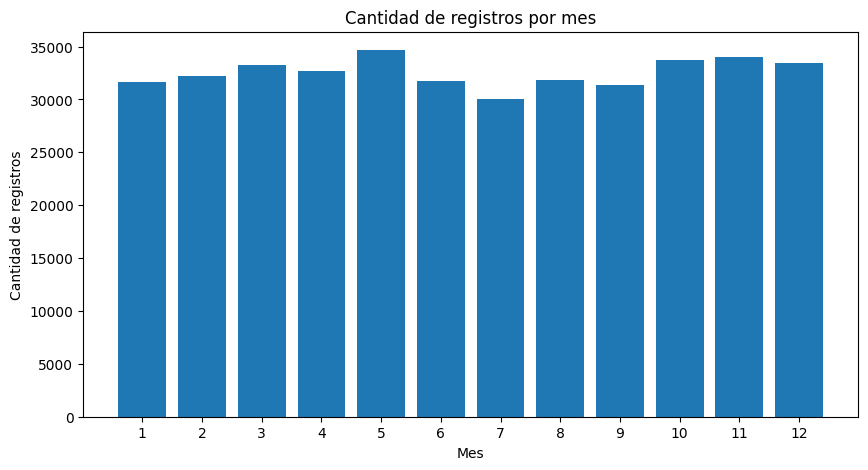

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(registros_por_mes["MES"], registros_por_mes["Cantidad de registros"])
plt.title("Cantidad de registros por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de registros")
plt.xticks(registros_por_mes["MES"])
plt.show()

También mostramos la distribución por día de la semana.

In [15]:
orden_dias_semana = ["lunes", "Martes", "Miercoles", "Jueves", "Viernes", "Sabado", "Domingo"]

registros_por_dia_semana = (
    dataset_raw["DIASEMANA"]
    .value_counts()
    .reindex(orden_dias_semana)
    .reset_index()
)
registros_por_dia_semana.columns = ["DIASEMANA", "Cantidad de registros"]

registros_por_dia_semana

,DIASEMANA,Cantidad de registros
0,lunes,69412
1,Martes,51215
2,Miercoles,51580
3,Jueves,50954
4,Viernes,56708
5,Sabado,58321
6,Domingo,52437


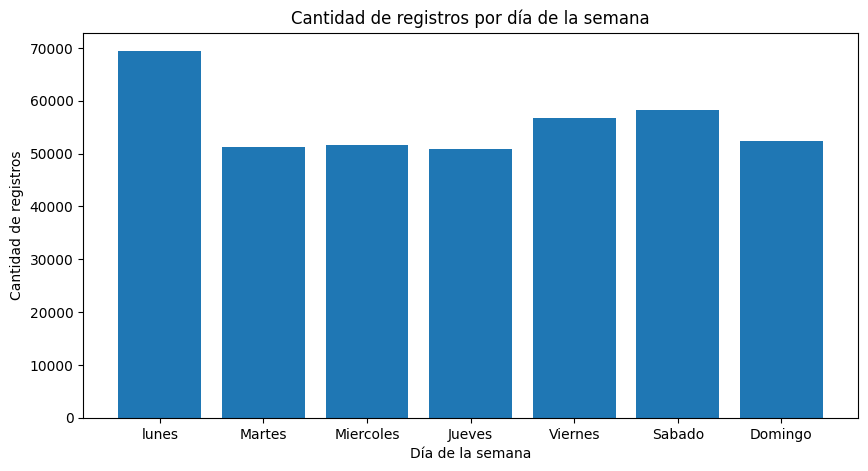

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(registros_por_dia_semana["DIASEMANA"], registros_por_dia_semana["Cantidad de registros"])
plt.title("Cantidad de registros por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de registros")
plt.show()

Finalmente, mostramos la distribución de los registros por hora.

In [17]:
registros_por_hora = dataset_raw["ID_HORA"].value_counts().sort_index().reset_index()
registros_por_hora.columns = ["ID_HORA", "Cantidad de registros"]

registros_por_hora

,ID_HORA,Cantidad de registros
0,0,9143
1,1,7400
2,2,6594
3,3,5694
4,4,4880
5,5,4986
6,6,8034
7,7,15159
8,8,20666
9,9,19486


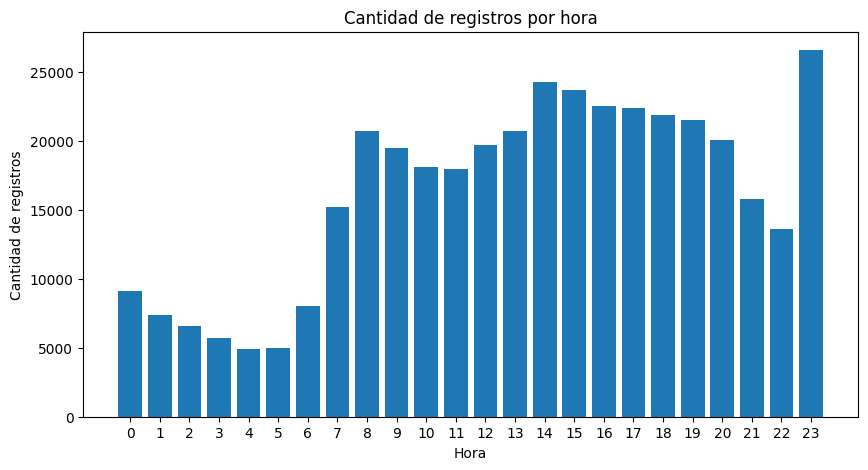

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(registros_por_hora["ID_HORA"], registros_por_hora["Cantidad de registros"])
plt.title("Cantidad de registros por hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad de registros")
plt.xticks(registros_por_hora["ID_HORA"])
plt.show()

Para evitar tablas demasiado extensas, en el caso del día del mes y los minutos mostramos únicamente los diez valores más frecuentes.

In [19]:
dias_mas_frecuentes = dataset_raw["ID_DIA"].value_counts().head(10).reset_index()
dias_mas_frecuentes.columns = ["ID_DIA", "Cantidad de registros"]

minutos_mas_frecuentes = dataset_raw["ID_MINUTO"].value_counts().head(10).reset_index()
minutos_mas_frecuentes.columns = ["ID_MINUTO", "Cantidad de registros"]

display(dias_mas_frecuentes)
display(minutos_mas_frecuentes)

,ID_DIA,Cantidad de registros
0,28,28734
1,14,12885
2,13,12860
3,15,12840
4,9,12826
5,16,12656
6,6,12609
7,19,12591
8,11,12484
9,10,12417


,ID_MINUTO,Cantidad de registros
0,0,58300
1,30,33707
2,20,22680
3,50,21725
4,40,21676
5,10,18857
6,15,14558
7,45,13602
8,35,9963
9,25,9805


Como vimos anteriormente, los registros con `Certificado cero` no representan accidentes reales. Para entender cómo afectan a las columnas temporales, revisamos qué valores tienen en el día del mes y en el día de la semana.

In [20]:
valores_temporales_certificado_cero = (
    dataset_raw.loc[dataset_raw["TIPACCID"] == "Certificado cero", ["ID_DIA", "DIASEMANA"]]
    .value_counts()
    .reset_index(name="Cantidad de registros")
)

valores_temporales_certificado_cero

,ID_DIA,DIASEMANA,Cantidad de registros
0,28,lunes,15678


Encontramos que todos los registros corresponden al año 2024, lo cual era esperado porque estamos trabajando con el dataset anual de ese periodo. La columna `ANIO` puede conservarse como referencia, pero no permitirá realizar comparaciones entre distintos años.

Las columnas `MES`, `ID_DIA`, `DIASEMANA`, `ID_HORA` e `ID_MINUTO` sí presentan variación y pueden ser útiles para analizar cuándo ocurren más accidentes. Sin embargo antes de sacar conclusiones tendremos que separar los registros con `Certificado cero`, ya que no representan accidentes reales.

Curiosamente, todos los registros con `Certificado cero` utilizan el día `28` y el valor `lunes`. Esto aumenta artificialmente la frecuencia de esos valores. También notamos que los minutos terminados en cero, como `00`, `30`, `20`, `50` y `40`, aparecen con mayor frecuencia. Más adelante convendrá tener presente que algunas horas podrían haber sido registradas de forma aproximada.

### 5.4 URBANA y SUBURBANA

Las columnas `URBANA` y `SUBURBANA` describen la zona donde ocurrió el accidente. Las analizamos en conjunto porque se complementan: cuando un registro corresponde a una zona urbana, la columna `SUBURBANA` indica `Sin accidente en esta zona`, y cuando corresponde a una zona suburbana ocurre lo contrario.

Para este análisis creamos una variable auxiliar sin los registros con `Certificado cero`, ya que estos no representan accidentes reales. El dataset original no se modifica.

In [21]:
dataset_accidentes = dataset_raw[dataset_raw["TIPACCID"] != "Certificado cero"]

print(f"Registros del dataset original: {len(dataset_raw)}")
print(f"Accidentes considerados en este análisis: {len(dataset_accidentes)}")

Registros del dataset original: 390627
Accidentes considerados en este análisis: 374949


Primero revisamos por separado la distribución de los valores de la columna `URBANA`.

In [22]:
registros_por_zona_urbana = dataset_accidentes["URBANA"].value_counts().reset_index()
registros_por_zona_urbana.columns = ["URBANA", "Cantidad de registros"]

registros_por_zona_urbana

,URBANA,Cantidad de registros
0,Accidente en intersección,259153
1,Accidente en no intersección,86281
2,Sin accidente en esta zona,29515


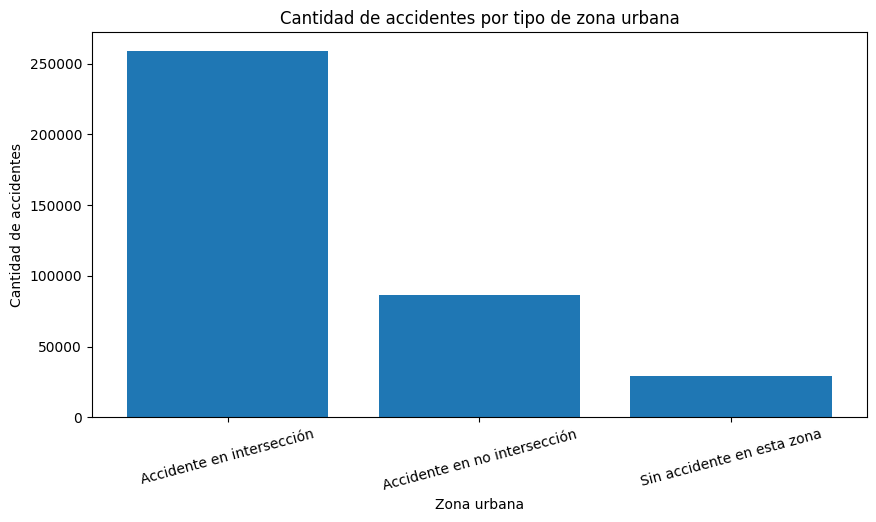

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(registros_por_zona_urbana["URBANA"], registros_por_zona_urbana["Cantidad de registros"])
plt.title("Cantidad de accidentes por tipo de zona urbana")
plt.xlabel("Zona urbana")
plt.ylabel("Cantidad de accidentes")
plt.xticks(rotation=15)
plt.show()

Ahora revisamos la distribución de los valores de la columna `SUBURBANA`.

In [24]:
registros_por_zona_suburbana = dataset_accidentes["SUBURBANA"].value_counts().reset_index()
registros_por_zona_suburbana.columns = ["SUBURBANA", "Cantidad de registros"]

registros_por_zona_suburbana

,SUBURBANA,Cantidad de registros
0,Sin accidente en esta zona,345434
1,Accidente en carretera estatal,20107
2,Accidentes en otro camino,5224
3,Accidente en camino rural,4184


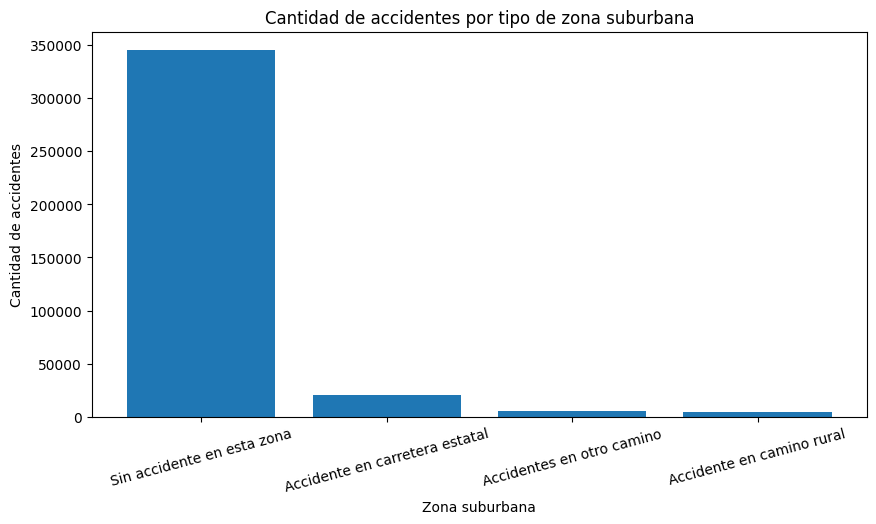

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(registros_por_zona_suburbana["SUBURBANA"], registros_por_zona_suburbana["Cantidad de registros"])
plt.title("Cantidad de accidentes por tipo de zona suburbana")
plt.xlabel("Zona suburbana")
plt.ylabel("Cantidad de accidentes")
plt.xticks(rotation=15)
plt.show()

Finalmente, creamos una tabla cruzada para comprobar cómo se relacionan ambas columnas.

In [26]:
relacion_zonas = pd.crosstab(dataset_accidentes["URBANA"], dataset_accidentes["SUBURBANA"])

relacion_zonas

SUBURBANA,Accidente en camino rural,Accidente en carretera estatal,Accidentes en otro camino,Sin accidente en esta zona
URBANA,,,,
Accidente en intersección,0,0,0,259153
Accidente en no intersección,0,0,0,86281
Sin accidente en esta zona,4184,20107,5224,0


Encontramos que 345,434 accidentes corresponden a zonas urbanas: 259,153 ocurrieron en intersecciones y 86,281 fuera de intersecciones. Tambien, 29,515 accidentes corresponden a zonas suburbanas: 20,107 ocurrieron en carreteras estatales, 5,224 en otros caminos y 4,184 en caminos rurales.

La tabla cruzada confirma que ambas columnas se complementan. Cuando `URBANA` contiene un tipo de accidente urbano, `SUBURBANA` tiene el valor `Sin accidente en esta zona`. Cuando el accidente corresponde a una zona suburbana ocurre lo contrario. Por esto, en análisis posteriores debemos interpretar ambas columnas en conjunto y no considerar `Sin accidente en esta zona` como un dato faltante.

### 5.5 TIPACCID

La columna `TIPACCID` indica el tipo de accidente de tránsito registrado. Para analizar su distribución utilizamos nuevamente la variable auxiliar `dataset_accidentes`, que excluye los registros con `Certificado cero` porque no representan accidentes reales.

In [27]:
registros_por_tipo_accidente = dataset_accidentes["TIPACCID"].value_counts().reset_index()
registros_por_tipo_accidente.columns = ["TIPACCID", "Cantidad de accidentes"]
registros_por_tipo_accidente["Porcentaje"] = (
    registros_por_tipo_accidente["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_tipo_accidente

,TIPACCID,Cantidad de accidentes,Porcentaje
0,Colisión con vehículo automotor,224720,59.93
1,Colisión con motocicleta,61869,16.50
2,Colisión con objeto fijo,43119,11.50
3,Volcadura,13371,3.57
4,Colisión con peatón (atropellamiento),11052,2.95
5,Salida del camino,10067,2.68
6,Colisión con ciclista,4033,1.08
7,Otro,2934,0.78
8,Caída de pasajero,2153,0.57
9,Colisión con animal,884,0.24


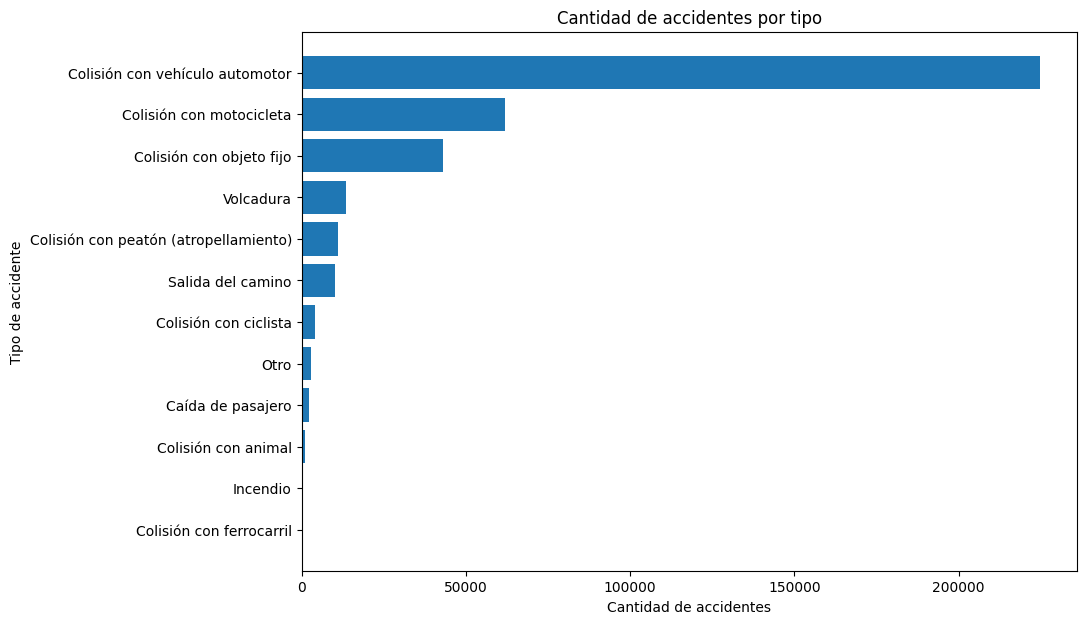

In [28]:
plt.figure(figsize=(10, 7))
plt.barh(registros_por_tipo_accidente["TIPACCID"], registros_por_tipo_accidente["Cantidad de accidentes"])
plt.title("Cantidad de accidentes por tipo")
plt.xlabel("Cantidad de accidentes")
plt.ylabel("Tipo de accidente")
plt.gca().invert_yaxis()
plt.show()

Encontramos que la categoría más frecuente es `Colisión con vehículo automotor` con 224,720 accidentes, lo que representa el 59.93% de los accidentes. Después aparecen `Colisión con motocicleta` con 61,869 registros y 16.50%, y `Colisión con objeto fijo` con 43,119 registros y 11.50%.

Estas tres categorías concentran la mayor parte de los accidentes del dataset. También encontramos categorías mucho menos frecuentes, como `Incendio` y `Colisión con ferrocarril`

### 5.6 Vehículos Involucrados

Las columnas `AUTOMOVIL`, `CAMPASAJ`, `MICROBUS`, `PASCAMION`, `OMNIBUS`, `TRANVIA`, `CAMIONETA`, `CAMION`, `TRACTOR`, `FERROCARRI`, `MOTOCICLET`, `BICICLETA` y `OTROVEHIC` indican la cantidad de vehículos involucrados en cada accidente según su categoría.

Continuamos utilizando `dataset_accidentes`, por lo que los registros con `Certificado cero` no se consideran en este análisis.

In [29]:
columnas_vehiculos = [
    "AUTOMOVIL", "CAMPASAJ", "MICROBUS", "PASCAMION", "OMNIBUS",
    "TRANVIA", "CAMIONETA", "CAMION", "TRACTOR", "FERROCARRI",
    "MOTOCICLET", "BICICLETA", "OTROVEHIC"
]

resumen_vehiculos = pd.DataFrame({
    "Tipo de vehículo": columnas_vehiculos,
    "Cantidad de vehículos": dataset_accidentes[columnas_vehiculos].sum().values,
    "Accidentes donde aparece": (dataset_accidentes[columnas_vehiculos] > 0).sum().values
})

total_vehiculos = resumen_vehiculos["Cantidad de vehículos"].sum()
resumen_vehiculos["Porcentaje del total de vehículos"] = (
    resumen_vehiculos["Cantidad de vehículos"] / total_vehiculos * 100
).round(2)
resumen_vehiculos["Porcentaje de accidentes donde aparece"] = (
    resumen_vehiculos["Accidentes donde aparece"] / len(dataset_accidentes) * 100
).round(2)

resumen_vehiculos = resumen_vehiculos.sort_values("Cantidad de vehículos", ascending=False)

print(f"Total de vehículos involucrados: {total_vehiculos}")
resumen_vehiculos

Total de vehículos involucrados: 710403


,Tipo de vehículo,Cantidad de vehículos,Accidentes donde aparece,Porcentaje del total de vehículos,Porcentaje de accidentes donde aparece
0,AUTOMOVIL,436681,302962,61.47,80.80
10,MOTOCICLET,86124,80101,12.12,21.36
1,CAMPASAJ,79558,69664,11.20,18.58
6,CAMIONETA,51106,47432,7.19,12.65
7,CAMION,16322,15828,2.30,4.22
3,PASCAMION,16068,15531,2.26,4.14
8,TRACTOR,10430,10089,1.47,2.69
12,OTROVEHIC,5801,5801,0.82,1.55
11,BICICLETA,4574,4532,0.64,1.21
4,OMNIBUS,1660,1625,0.23,0.43


Para comparar las categorías con mayor claridad mostramos una gráfica con la cantidad total de vehículos involucrados de cada tipo.

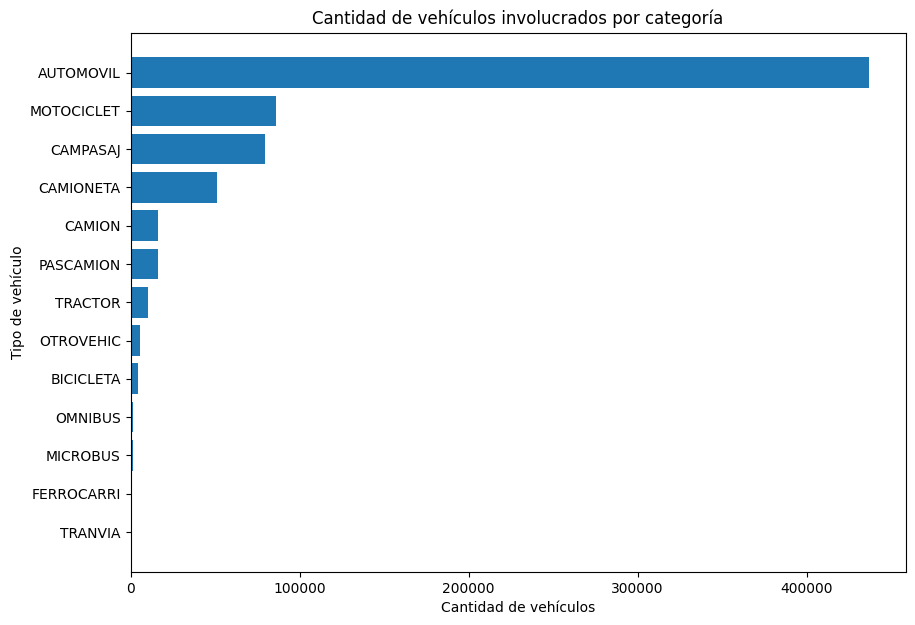

In [30]:
plt.figure(figsize=(10, 7))
plt.barh(resumen_vehiculos["Tipo de vehículo"], resumen_vehiculos["Cantidad de vehículos"])
plt.title("Cantidad de vehículos involucrados por categoría")
plt.xlabel("Cantidad de vehículos")
plt.ylabel("Tipo de vehículo")
plt.gca().invert_yaxis()
plt.show()

También calculamos la cantidad total de vehículos involucrados en cada accidente. Esto nos permite observar si normalmente participa un solo vehículo o varios.

In [31]:
vehiculos_por_accidente = dataset_accidentes[columnas_vehiculos].sum(axis=1)

distribucion_vehiculos_por_accidente = vehiculos_por_accidente.value_counts().sort_index().reset_index()
distribucion_vehiculos_por_accidente.columns = ["Cantidad de vehículos", "Cantidad de accidentes"]

print(f"Promedio de vehículos por accidente: {vehiculos_por_accidente.mean():.2f}")
distribucion_vehiculos_por_accidente

Promedio de vehículos por accidente: 1.89


,Cantidad de vehículos,Cantidad de accidentes
0,1,61910
1,2,294083
2,3,16313
3,4,2083
4,5,391
5,6,113
6,7,34
7,8,14
8,9,7
9,10,1


Encontramos un total de 710,403 vehículos involucrados en los accidentes registrados. La categoría más fuerte es `AUTOMOVIL`, con 436,681 vehículos lo que representa el 61.47% del total. Después aparecen `MOTOCICLET` con 86,124 vehículos y 12.12%, y `CAMPASAJ`, con 79,558 vehículos y 11.20%.

También vemos que un mismo accidente puede involucrar vehículos de distintas categorías, por lo que estas columnas no deben interpretarse de forma aislada ni como categorías excluyentes.

El promedio es de 1.89 vehículos por accidente. La mayoría de los accidentes, aprox 294,083 registros, involucran exactamente dos vehículos

### 5.7 CAUSAACCI

La columna `CAUSAACCI` indica la posible causa o determinante del accidente. De acuerdo con el diccionario de datos, esta causa puede atribuirse al conductor, a un peatón o pasajero, a una falla del vehículo, a una mala condición del camino o a otra causa

In [32]:
registros_por_causa = dataset_accidentes["CAUSAACCI"].value_counts().reset_index()
registros_por_causa.columns = ["CAUSAACCI", "Cantidad de accidentes"]
registros_por_causa["Porcentaje"] = (
    registros_por_causa["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_causa

,CAUSAACCI,Cantidad de accidentes,Porcentaje
0,Conductor,360051,96.03
1,Mala condición del camino,5991,1.60
2,Falla del vehículo,3978,1.06
3,Otra,2639,0.70
4,Peatón o pasajero,2290,0.61


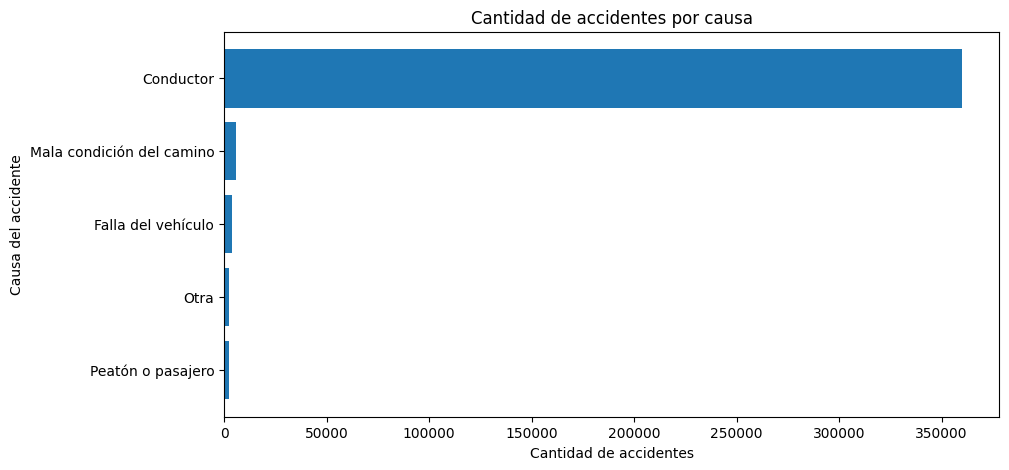

In [33]:
plt.figure(figsize=(10, 5))
plt.barh(registros_por_causa["CAUSAACCI"], registros_por_causa["Cantidad de accidentes"])
plt.title("Cantidad de accidentes por causa")
plt.xlabel("Cantidad de accidentes")
plt.ylabel("Causa del accidente")
plt.gca().invert_yaxis()
plt.show()

Encontramos que la categoría `Conductor` concentra 360,051 registros, lo que representa el 96.03% de los accidentes considerados. Las demás categorías aparecen con una frecuencia mucho menor: `Mala condición del camino` representa el 1.60%, `Falla del vehículo` el 1.06%, `Otra` el 0.70% y `Peatón o pasajero` el 0.61%.

La distribución está fuertemente concentrada en una sola categoría. Esto deberá tomarse en cuenta en análisis posteriores, ya que comparar las causas únicamente por cantidad puede ocultar las diferencias entre los grupos menos frecuentes.

También es importante recordar que el diccionario describe esta variable como una causa presunta o determinante registrada en el dataset. Por lo tanto, estos valores deben interpretarse como una clasificación del accidente y no como una demostración independiente de causalidad.

### 5.8 CAPAROD

La columna `CAPAROD` indica el tipo de superficie de rodamiento donde ocurrió el accidente, es decir, el tipo de suelo donde ocurrio. De acuerdo con el diccionario de datos, esta superficie puede clasificarse como pavimentada o no pavimentada.

Para analizar su distribución utilizamos `dataset_accidentes`, por lo que los registros con `Certificado cero` no se consideran.

In [34]:
registros_por_superficie = dataset_accidentes["CAPAROD"].value_counts().reset_index()
registros_por_superficie.columns = ["CAPAROD", "Cantidad de accidentes"]
registros_por_superficie["Porcentaje"] = (
    registros_por_superficie["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_superficie

,CAPAROD,Cantidad de accidentes,Porcentaje
0,Pavimentada,368913,98.39
1,No Pavimentada,6036,1.61


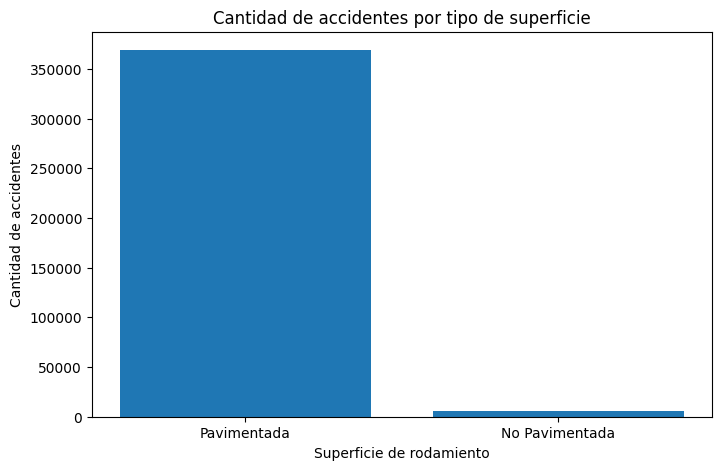

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(registros_por_superficie["CAPAROD"], registros_por_superficie["Cantidad de accidentes"])
plt.title("Cantidad de accidentes por tipo de superficie")
plt.xlabel("Superficie de rodamiento")
plt.ylabel("Cantidad de accidentes")
plt.show()

Encontramos que 368,913 accidentes ocurrieron sobre superficies pavimentadas, lo que representa el 98.39% de los accidentes. En comparación con 6,036 accidentes que ocurrieron sobre terreno no pavimentado

La gran mayoría de los accidentes registrados ocurrieron en superficies pavimentadas. Sin embargo, este resultado no permite concluir por sí solo que estas superficies sean más peligrosas, ya que el dataset no indica cuántas vialidades o cuántos desplazamientos corresponden a cada tipo de superficie.

### 5.9 SEXO e ID_EDAD

Las columnas `SEXO` e `ID_EDAD` describen al posible conductor responsable del accidente. Las analizamos en conjunto porque algunos valores de edad tienen un significado especial relacionado con la información disponible sobre el conductor.

Para este análisis utilizamos `dataset_accidentes`, por lo que los registros con `Certificado cero` no se consideran.

Primero revisamos la distribución de la columna `SEXO`.

In [36]:
registros_por_sexo = dataset_accidentes["SEXO"].value_counts().reset_index()
registros_por_sexo.columns = ["SEXO", "Cantidad de accidentes"]
registros_por_sexo["Porcentaje"] = (
    registros_por_sexo["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_sexo

,SEXO,Cantidad de accidentes,Porcentaje
0,Hombre,278004,74.14
1,Mujer,61908,16.51
2,Se fugó,35037,9.34


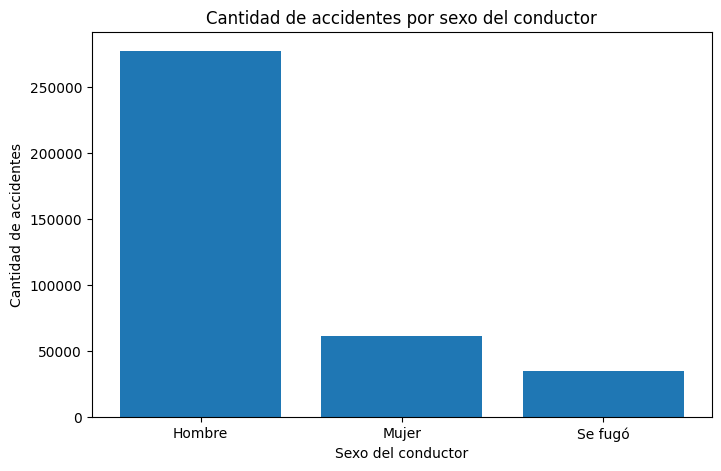

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(registros_por_sexo["SEXO"], registros_por_sexo["Cantidad de accidentes"])
plt.title("Cantidad de accidentes por sexo del conductor")
plt.xlabel("Sexo del conductor")
plt.ylabel("Cantidad de accidentes")
plt.show()

Antes de calcular estadísticas de edad, revisamos los códigos especiales que dijimos en el diccionario de datos. El valor `0` indica que el conductor se fugó y el valor `99` indica que se desconoce su edad.

In [38]:
edades_especiales = pd.DataFrame({
    "Código": [0, 99],
    "Significado": ["El conductor se fugó", "Se desconoce la edad del conductor"],
    "Cantidad de registros": [
        (dataset_accidentes["ID_EDAD"] == 0).sum(),
        (dataset_accidentes["ID_EDAD"] == 99).sum()
    ]
})

edades_especiales

,Código,Significado,Cantidad de registros
0,0,El conductor se fugó,35037
1,99,Se desconoce la edad del conductor,61564


Ahora creamos una variable auxiliar que contiene únicamente edades válidas, es decir, valores distintos de `0` y `99`. El dataset original no se modifica.

In [39]:
conductores_con_edad_valida = dataset_accidentes[~dataset_accidentes["ID_EDAD"].isin([0, 99])]

resumen_edades = conductores_con_edad_valida["ID_EDAD"].describe().round(2)

print(f"Conductores con edad válida: {len(conductores_con_edad_valida)}")
resumen_edades

Conductores con edad válida: 278348


count    278348.00
mean         37.85
std          14.61
min          12.00
25%          26.00
50%          35.00
75%          47.00
max          98.00
Name: ID_EDAD, dtype: float64

Finalmente, mostramos la distribución de las edades válidas diferenciando entre hombres y mujeres.

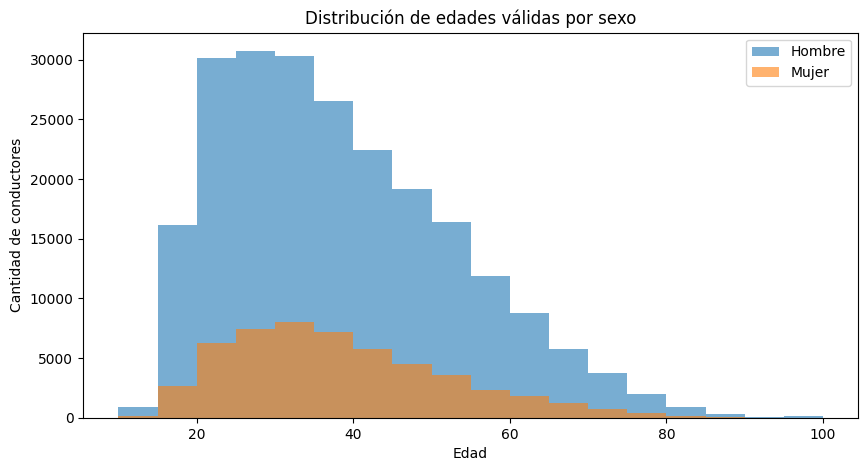

In [40]:
plt.figure(figsize=(10, 5))
plt.hist(
    conductores_con_edad_valida.loc[conductores_con_edad_valida["SEXO"] == "Hombre", "ID_EDAD"],
    bins=range(10, 101, 5), alpha=0.6, label="Hombre"
)
plt.hist(
    conductores_con_edad_valida.loc[conductores_con_edad_valida["SEXO"] == "Mujer", "ID_EDAD"],
    bins=range(10, 101, 5), alpha=0.6, label="Mujer"
)
plt.title("Distribución de edades válidas por sexo")
plt.xlabel("Edad")
plt.ylabel("Cantidad de conductores")
plt.legend()
plt.show()

Encontramos que 278,004 accidentes, equivalentes al 74.14% tienen registrado a un conductor hombre como presunto responsable. En 61,908 registros, equivalentes al 16.51% se registra una mujer. Además, en 35,037 casos el conductor se fugó y no fue posible registrar su sexo.

En la columna `ID_EDAD` los 35,037 registros con valor `0` corresponden precisamente a los casos donde el conductor se fugó. También encontramos 61,564 registros con valor `99`, que indican que se desconoce la edad del conductor. Estos códigos no deben incluirse al calcular promedios o analizar la distribución de edades.

Después de excluir los códigos especiales quedan 278,348 conductores con edades válidas entre 12 y 98 años. La edad promedio es de 37.85 años y la mediana es de 35 años. La distribución se concentra principalmente entre los 18 y los 49 años.

### 5.10 ALIENTO

La columna `ALIENTO` indica si el conductor presunto responsable presentaba aliento alcohólico. De acuerdo con el diccionario de datos, sus posibles valores son `Sí`, `No` y `Se ignora`.

Para analizar su distribución utilizamos `dataset_accidentes`, por lo que los registros con `Certificado cero` no se consideran.

In [41]:
registros_por_aliento = dataset_accidentes["ALIENTO"].value_counts().reset_index()
registros_por_aliento.columns = ["ALIENTO", "Cantidad de accidentes"]
registros_por_aliento["Porcentaje"] = (
    registros_por_aliento["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_aliento

,ALIENTO,Cantidad de accidentes,Porcentaje
0,No,239170,63.79
1,Se ignora,119864,31.97
2,Sí,15915,4.24


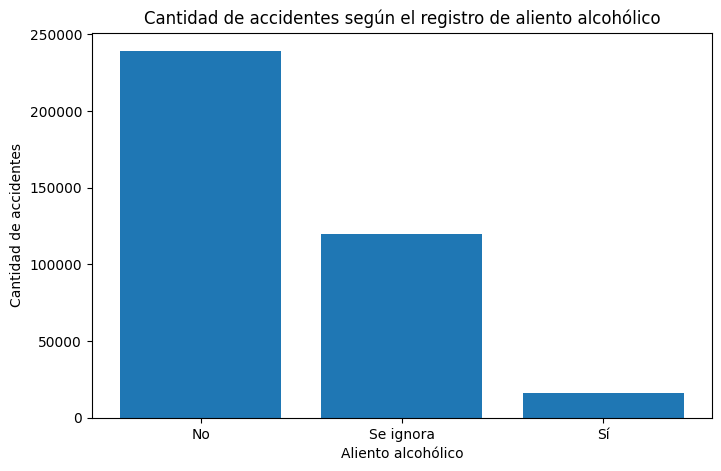

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(registros_por_aliento["ALIENTO"], registros_por_aliento["Cantidad de accidentes"])
plt.title("Cantidad de accidentes según el registro de aliento alcohólico")
plt.xlabel("Aliento alcohólico")
plt.ylabel("Cantidad de accidentes")
plt.show()

Debido a que existen registros con valor `Se ignora`, también calculamos los porcentajes considerando únicamente los casos donde sí se conoce esta información.

In [43]:
aliento_conocido = dataset_accidentes[dataset_accidentes["ALIENTO"] != "Se ignora"]

registros_por_aliento_conocido = aliento_conocido["ALIENTO"].value_counts().reset_index()
registros_por_aliento_conocido.columns = ["ALIENTO", "Cantidad de accidentes"]
registros_por_aliento_conocido["Porcentaje entre casos conocidos"] = (
    registros_por_aliento_conocido["Cantidad de accidentes"] / len(aliento_conocido) * 100
).round(2)

registros_por_aliento_conocido

,ALIENTO,Cantidad de accidentes,Porcentaje entre casos conocidos
0,No,239170,93.76
1,Sí,15915,6.24


Vemos que en 239,170 accidentes, equivalentes al 63.79%, se registró que el conductor no tenia aliento alcohólico. En 15,915 casos, equivalentes al 4.24%, se registró que sí.

Sin embargo, en 119,864 accidentes se desconoce esta información. Al considerar únicamente los 255,085 casos conocidos, el porcentaje de registros con aliento alcohólico es de 6.24%.

La cantidad de valores `Se ignora` es considerable y deberá tomarse en cuenta en análisis posteriores. Además, esta columna indica el registro de aliento alcohólico del conductor presunto responsable, pero por sí sola no permite determinar el grado de consumo ni afirmar que el alcohol fue la causa del accidente.

### 5.11 CINTURON

La columna `CINTURON` indica si el conductor presunto responsable utilizaba cinturón de seguridad. De acuerdo con el diccionario de datos, sus posibles valores son `Sí`, `No` y `Se ignora`.

In [44]:
registros_por_cinturon = dataset_accidentes["CINTURON"].value_counts().reset_index()
registros_por_cinturon.columns = ["CINTURON", "Cantidad de accidentes"]
registros_por_cinturon["Porcentaje"] = (
    registros_por_cinturon["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_cinturon

,CINTURON,Cantidad de accidentes,Porcentaje
0,Se ignora,289213,77.13
1,No,43285,11.54
2,Sí,42451,11.32


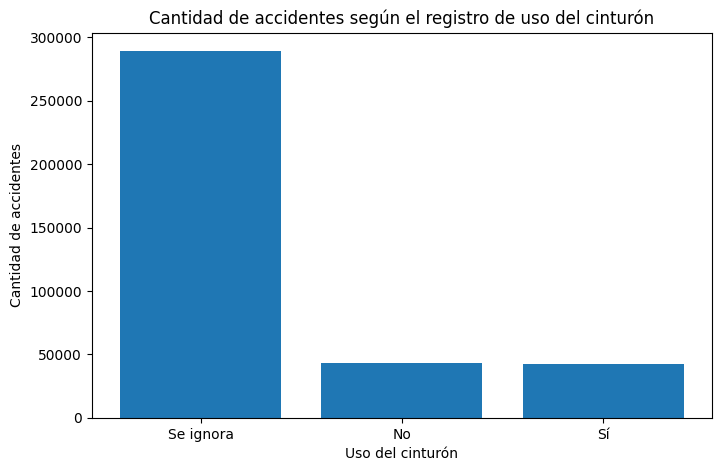

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(registros_por_cinturon["CINTURON"], registros_por_cinturon["Cantidad de accidentes"])
plt.title("Cantidad de accidentes según el registro de uso del cinturón")
plt.xlabel("Uso del cinturón")
plt.ylabel("Cantidad de accidentes")
plt.show()

Debido a que existen registros con valor `Se ignora`, también calculamos los porcentajes considerando únicamente los casos donde sí se conoce esta información.

In [46]:
cinturon_conocido = dataset_accidentes[dataset_accidentes["CINTURON"] != "Se ignora"]

registros_por_cinturon_conocido = cinturon_conocido["CINTURON"].value_counts().reset_index()
registros_por_cinturon_conocido.columns = ["CINTURON", "Cantidad de accidentes"]
registros_por_cinturon_conocido["Porcentaje entre casos conocidos"] = (
    registros_por_cinturon_conocido["Cantidad de accidentes"] / len(cinturon_conocido) * 100
).round(2)

registros_por_cinturon_conocido

,CINTURON,Cantidad de accidentes,Porcentaje entre casos conocidos
0,No,43285,50.49
1,Sí,42451,49.51


Encontramos que en 42,451 accidentes, equivalentes al 11.32%, se registró que el conductor utilizaba cinturón de seguridad. En 43,285 casos, equivalentes al 11.54%, se registró que no lo utilizaba.

Sin embargo, en 289,213 accidentes, equivalentes al 77.13%, se desconoce esta información. Al considerar únicamente los 85,736 casos conocidos, el 49.51% utilizaba cinturón y el 50.49% no lo utilizaba.

La cantidad de valores `Se ignora` es muy alta, por lo que la información disponible es limitada. Esto deberá tomarse en cuenta si más adelante queremos relacionar el uso del cinturón con la gravedad de los accidentes. Además, la columna se refiere únicamente al conductor presunto responsable y no informa si los demás ocupantes utilizaban cinturón.

### 5.12 Personas Heridas y Fallecidas

Las columnas `CONDMUERTO`, `CONDHERIDO`, `PASAMUERTO`, `PASAHERIDO`, `PEATMUERTO`, `PEATHERIDO`, `CICLMUERTO`, `CICLHERIDO`, `OTROMUERTO`, `OTROHERIDO`, `NEMUERTO` y `NEHERIDO` indican la cantidad de personas heridas y fallecidas según el tipo de persona involucrada en el accidente.

También incluimos `NEMUERTO` y `NEHERIDO`, que corresponden a víctimas no especificadas

In [47]:
resumen_victimas = pd.DataFrame({
    "Tipo de persona": ["Conductor", "Pasajero", "Peatón", "Ciclista", "Otra persona", "No especificado"],
    "Personas fallecidas": [
        dataset_accidentes["CONDMUERTO"].sum(),
        dataset_accidentes["PASAMUERTO"].sum(),
        dataset_accidentes["PEATMUERTO"].sum(),
        dataset_accidentes["CICLMUERTO"].sum(),
        dataset_accidentes["OTROMUERTO"].sum(),
        dataset_accidentes["NEMUERTO"].sum()
    ],
    "Personas heridas": [
        dataset_accidentes["CONDHERIDO"].sum(),
        dataset_accidentes["PASAHERIDO"].sum(),
        dataset_accidentes["PEATHERIDO"].sum(),
        dataset_accidentes["CICLHERIDO"].sum(),
        dataset_accidentes["OTROHERIDO"].sum(),
        dataset_accidentes["NEHERIDO"].sum()
    ]
})

resumen_victimas

,Tipo de persona,Personas fallecidas,Personas heridas
0,Conductor,2614,45442
1,Pasajero,972,26828
2,Peatón,901,11509
3,Ciclista,142,2097
4,Otra persona,27,104
5,No especificado,0,0


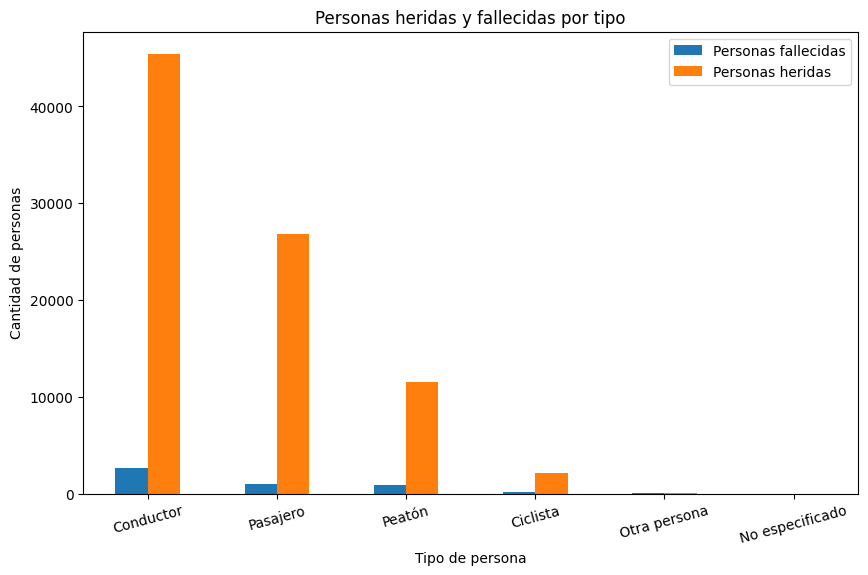

In [48]:
resumen_victimas.plot(
    x="Tipo de persona",
    y=["Personas fallecidas", "Personas heridas"],
    kind="bar",
    figsize=(10, 6)
)
plt.title("Personas heridas y fallecidas por tipo")
plt.xlabel("Tipo de persona")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=15)
plt.show()

También calculamos los totales generales y la cantidad de accidentes donde se registró al menos una persona herida o fallecida.

In [49]:
columnas_fallecidos = ["CONDMUERTO", "PASAMUERTO", "PEATMUERTO", "CICLMUERTO", "OTROMUERTO", "NEMUERTO"]
columnas_heridos = ["CONDHERIDO", "PASAHERIDO", "PEATHERIDO", "CICLHERIDO", "OTROHERIDO", "NEHERIDO"]

total_fallecidos = dataset_accidentes[columnas_fallecidos].sum().sum()
total_heridos = dataset_accidentes[columnas_heridos].sum().sum()
accidentes_con_fallecidos = (dataset_accidentes[columnas_fallecidos].sum(axis=1) > 0).sum()
accidentes_con_heridos = (dataset_accidentes[columnas_heridos].sum(axis=1) > 0).sum()

print(f"Total de personas fallecidas: {total_fallecidos}")
print(f"Total de personas heridas: {total_heridos}")
print(f"Accidentes con al menos una persona fallecida: {accidentes_con_fallecidos}")
print(f"Accidentes con al menos una persona herida: {accidentes_con_heridos}")

Total de personas fallecidas: 4656
Total de personas heridas: 85980
Accidentes con al menos una persona fallecida: 4188
Accidentes con al menos una persona herida: 64845


Encontramos un total de 4,656 personas fallecidas y 85,980 personas heridas. Los conductores concentran la mayor cantidad de víctimas: 2,614 fallecidos y 45,442 heridos. Después aparecen los pasajeros, con 972 fallecidos y 26,828 heridos, y los peatones, con 901 fallecidos y 11,509 heridos.

También encontramos 142 ciclistas fallecidos y 2,097 heridos, además de 27 personas fallecidas y 104 heridas clasificadas como otras personas involucradas. Las columnas `NEMUERTO` y `NEHERIDO`, correspondientes a víctimas no especificadas, tienen valor cero en todos los registros

En total, 4,188 accidentes registran al menos una persona fallecida y 64,845 registran al menos una persona herida. Hayq ue recordar que estas columnas contienen cantidades de personas, por lo que el total de víctimas no equivale al número de accidentes.

### 5.13 CLASACC

La columna `CLASACC` indica la clasificación del accidente según su gravedad. De acuerdo con el diccionario de datos, los accidentes pueden clasificarse como `Fatal`, `No fatal` o `Sólo daños`.

Para analizar su distribución utilizamos `dataset_accidentes`, por lo que los registros con `Certificado cero` no se consideran.

In [50]:
registros_por_clasificacion = dataset_accidentes["CLASACC"].value_counts().reset_index()
registros_por_clasificacion.columns = ["CLASACC", "Cantidad de accidentes"]
registros_por_clasificacion["Porcentaje"] = (
    registros_por_clasificacion["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_clasificacion

,CLASACC,Cantidad de accidentes,Porcentaje
0,Sólo daños,306841,81.84
1,No fatal,63920,17.05
2,Fatal,4188,1.12


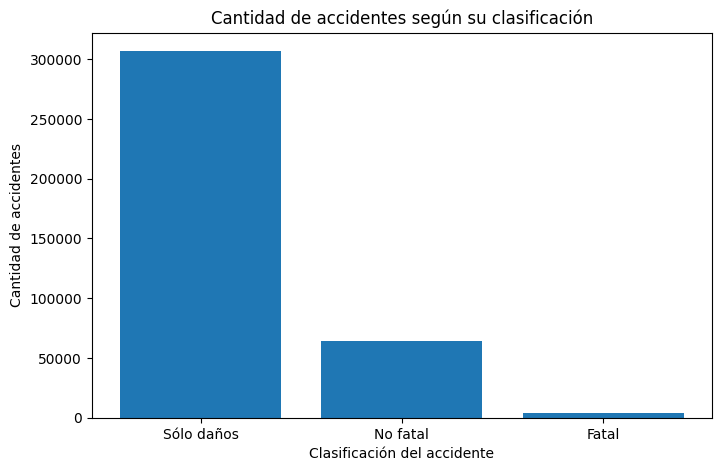

In [51]:
plt.figure(figsize=(8, 5))
plt.bar(registros_por_clasificacion["CLASACC"], registros_por_clasificacion["Cantidad de accidentes"])
plt.title("Cantidad de accidentes según su clasificación")
plt.xlabel("Clasificación del accidente")
plt.ylabel("Cantidad de accidentes")
plt.show()

Encontramos que 306,841 accidentes se clasifican como `Sólo daños`. En 63,920 casos se registraron personas heridas y el accidente se clasificó como `No fatal`. Finalmente, 4,188 accidentes se clasifican como `Fatal`.

La mayoría de los accidentes ocasionó únicamente daños materiales. Sin embargo, los accidentes no fatales y fatales siguen representando una cantidad importante de registros por sus consecuencias humanas.

La cantidad de accidentes clasificados como `Fatal` coincide con los 4,188 accidentes donde anteriormente encontramos al menos una persona fallecida. Esta correspondencia es consistente con la definición indicada en el diccionario de datos.

Esta será una de las variables más importantes del proyecto. En la parte de aprendizaje supervisado utilizaremos `CLASACC` como variable objetivo para construir un modelo de clasificación que intente predecir la gravedad del accidente. Como las categorías no están equilibradas, especialmente la clase `Fatal`, tendremos que considerar este desbalance al evaluar el modelo.

En cambio, para el análisis de agrupamiento eliminaremos `CLASACC` de las variables utilizadas por el algoritmo. El objetivo será formar grupos a partir de las características de los accidentes sin proporcionar previamente su clasificación.

### 5.14 ESTATUS

La ulitma columna, `ESTATUS`, indica el estado de las cifras publicadas por INEGI. De acuerdo con el diccionario de datos, los registros pueden corresponder a cifras definitivas, preliminares, revisadas o corregidas.

Para analizar su distribución utilizamos `dataset_accidentes`, por lo que los registros con `Certificado cero` no se consideran.

In [52]:
registros_por_estatus = dataset_accidentes["ESTATUS"].value_counts().reset_index()
registros_por_estatus.columns = ["ESTATUS", "Cantidad de accidentes"]
registros_por_estatus["Porcentaje"] = (
    registros_por_estatus["Cantidad de accidentes"] / len(dataset_accidentes) * 100
).round(2)

registros_por_estatus

,ESTATUS,Cantidad de accidentes,Porcentaje
0,Cifras Definitivas,356109,94.98
1,Cifras Corregidas,18840,5.02


Para comparar los valores registrados con mayor claridad, mostramos una gráfica de barras.

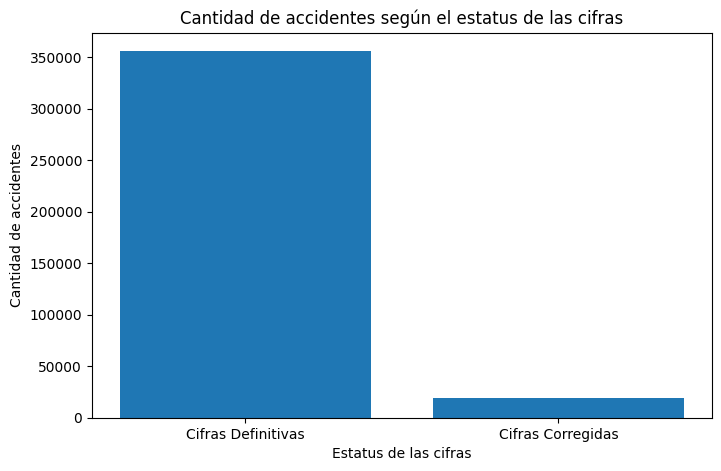

In [53]:
plt.figure(figsize=(8, 5))
plt.bar(registros_por_estatus["ESTATUS"], registros_por_estatus["Cantidad de accidentes"])
plt.title("Cantidad de accidentes según el estatus de las cifras")
plt.xlabel("Estatus de las cifras")
plt.ylabel("Cantidad de accidentes")
plt.show()

Encontramos que 356,109 accidentes  corresponden a `Cifras Definitivas`. Los 18,840 registros restantescorresponden a `Cifras Corregidas`. Aunque el diccionario contempla cifras preliminares y revisadas, estos valores no aparecen en el dataset analizado.

Esta variable describe el estado de publicación de la información y no una característica del accidente. Puede conservarse como referencia para conocer la procedencia de los registros, pero probablemente no convenga utilizarla como variable predictora en los modelos de aprendizaje automático ni para formar grupos en el análisis de agrupamiento.

## **6. Limpieza del Dataset**

### 6.1 Filas Duplicadas

En la sección 4.2 identificamos 871 filas con valores idénticos en todas sus columnas (≈0.22%
del dataset). Antes de eliminarlas, inspeccionamos su contenido para evaluar si podrían
corresponder a accidentes distintos con las mismas características.

In [54]:
duplicados = dataset_raw[dataset_raw.duplicated(keep=False)].sort_values(
    by=["ID_ENTIDAD", "ID_MUNICIPIO", "MES", "ID_DIA", "ID_HORA", "ID_MINUTO"]
)

print(f"Registros involucrados (originales + duplicados): {len(duplicados)}")
duplicados[["ID_ENTIDAD", "ID_MUNICIPIO", "MES", "ID_DIA", "ID_HORA", "ID_MINUTO",
            "TIPACCID", "CAUSAACCI", "SEXO", "ID_EDAD", "CLASACC"]].head(20)

Registros involucrados (originales + duplicados): 1678


,ID_ENTIDAD,ID_MUNICIPIO,MES,ID_DIA,ID_HORA,ID_MINUTO,TIPACCID,CAUSAACCI,SEXO,ID_EDAD,CLASACC
4073,1,7,9,30,13,25,Colisión con vehículo automotor,Conductor,Mujer,21,Sólo daños
4074,1,7,9,30,13,25,Colisión con vehículo automotor,Conductor,Mujer,21,Sólo daños
4377,2,1,1,9,10,22,Colisión con vehículo automotor,Conductor,Hombre,41,Sólo daños
4378,2,1,1,9,10,22,Colisión con vehículo automotor,Conductor,Hombre,41,Sólo daños
4474,2,1,1,18,15,25,Colisión con vehículo automotor,Conductor,Hombre,22,Sólo daños
4475,2,1,1,18,15,25,Colisión con vehículo automotor,Conductor,Hombre,22,Sólo daños
4697,2,1,2,6,17,40,Colisión con vehículo automotor,Conductor,Mujer,37,Sólo daños
4698,2,1,2,6,17,40,Colisión con vehículo automotor,Conductor,Mujer,37,Sólo daños
5124,2,1,3,11,5,22,Colisión con objeto fijo,Conductor,Hombre,31,Sólo daños
5125,2,1,3,11,5,22,Colisión con objeto fijo,Conductor,Hombre,31,Sólo daños


La inspección confirma que los registros duplicados coinciden en todas las variables relevantes:
ubicación exacta, momento del accidente (hasta el minuto), tipo de percance, causa presunta,
características del conductor y severidad. Que dos accidentes independientes compartan
simultáneamente todos estos atributos es estadísticamente improbable, por lo que se concluye
que se deben a errores de captura o registros duplicados en la fuente.

**Decisión:** Se eliminan las 871 filas duplicadas conservando una única ocurrencia de cada
registro. El dataset original `dataset_raw` no se modifica; a partir de este punto se trabaja
sobre `dataset_limpio`.

In [55]:
dataset_limpio = dataset_raw.drop_duplicates().copy()

filas_eliminadas = len(dataset_raw) - len(dataset_limpio)
duplicados_restantes = dataset_limpio.duplicated().sum()

print(f"Filas antes de eliminar duplicados: {len(dataset_raw)}")
print(f"Filas eliminadas: {filas_eliminadas}")
print(f"Filas después de eliminar duplicados: {len(dataset_limpio)}")
print(f"Duplicados restantes: {duplicados_restantes}")

Filas antes de eliminar duplicados: 390627
Filas eliminadas: 871
Filas después de eliminar duplicados: 389756
Duplicados restantes: 0


Después de eliminar las repeticiones exactas, el dataset pasa de 390,627 a 389,756 filas. Se eliminaron 871 filas duplicadas y no quedan duplicados exactos. A partir de este punto utilizaremos `dataset_limpio` para continuar con el proceso de limpieza.

### 6.2 Columnas sin Variación

Durante el análisis de calidad identificamos cuatro columnas que contienen un solo valor en todos sus registros: `COBERTURA`, `ANIO`, `NEMUERTO` y `NEHERIDO`.

Estas variables no permiten distinguir entre accidentes ni aportan información para realizar comparaciones, formar grupos o construir modelos predictivos. Por esta razón, tomamos la decisión de eliminarlas de `dataset_limpio`.

La eliminación no implica que estas columnas sean incorrectas. Por ejemplo, `COBERTURA` indica que todo el dataset se encuentra a nivel municipal y `ANIO` confirma que todos los registros corresponden a 2024. Sin embargo, su información ya quedó documentada durante el análisis exploratorio y no es necesario conservarlas para las siguientes etapas.

In [56]:
columnas_sin_variacion = ["COBERTURA", "ANIO", "NEMUERTO", "NEHERIDO"]

dataset_limpio = dataset_limpio.drop(columns=columnas_sin_variacion)

print(f"Columnas eliminadas: {columnas_sin_variacion}")
print(f"Cantidad de columnas restantes: {dataset_limpio.shape[1]}")
print(f"Columnas eliminadas que permanecen en el dataset: {set(columnas_sin_variacion) & set(dataset_limpio.columns)}")

Columnas eliminadas: ['COBERTURA', 'ANIO', 'NEMUERTO', 'NEHERIDO']
Cantidad de columnas restantes: 41
Columnas eliminadas que permanecen en el dataset: set()


Después de eliminar las columnas sin variación, `dataset_limpio` pasa de 45 a 41 columnas

### 6.3 Registros con Certificado Cero

En la sección 4.4 identificamos 15,678 registros donde `TIPACCID` contiene el valor
`Certificado cero`. De acuerdo con la documentación oficial del INEGI, estos registros
corresponden a municipios que informaron formalmente la ausencia de accidentes viales en su
jurisdicción y no representan percances reales.

Antes de eliminarlos, inspeccionamos una muestra para verificar que el resto de sus columnas
tampoco contiene información útil sobre accidentes.

In [57]:
columnas_inspeccion = [
    "ID_ENTIDAD", "ID_MUNICIPIO", "MES", "ID_DIA", "DIASEMANA",
    "TIPACCID", "CAUSAACCI", "URBANA", "SEXO", "ID_EDAD",
    "AUTOMOVIL", "MOTOCICLET", "CONDMUERTO", "CONDHERIDO",
    "PASAMUERTO", "PASAHERIDO", "CLASACC"
]

muestra_certificado_cero = (
    dataset_raw[dataset_raw["TIPACCID"] == "Certificado cero"][columnas_inspeccion]
    .sample(10, random_state=42)
)

muestra_certificado_cero

,ID_ENTIDAD,ID_MUNICIPIO,MES,ID_DIA,DIASEMANA,TIPACCID,CAUSAACCI,URBANA,SEXO,ID_EDAD,AUTOMOVIL,MOTOCICLET,CONDMUERTO,CONDHERIDO,PASAMUERTO,PASAHERIDO,CLASACC
277266,20,405,12,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
273704,20,185,8,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
274646,20,263,7,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
269881,20,52,4,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
275738,20,335,1,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
376277,30,171,9,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
275273,20,304,10,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
367470,30,17,8,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
117373,12,40,8,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños
132142,14,40,3,28,lunes,Certificado cero,Certificado cero,Sin accidente en esta zona,Certificado cero,0,0,0,0,0,0,0,Sólo daños


La muestra confirma el patrón descrito: todos los registros con `Certificado cero` presentan
valores genéricos en el resto de las columnas. Las variables de conteo de vehículos y víctimas
son cero, `CLASACC` siempre es `Sólo daños`, y los campos de conductor como `SEXO` y `ID_EDAD`
contienen valores que tampoco representan información real. Su eliminación no implica pérdida
de información sobre accidentes.

In [58]:
certificados_cero_en_dataset_limpio = (dataset_limpio["TIPACCID"] == "Certificado cero").sum()

dataset_limpio = dataset_limpio[dataset_limpio["TIPACCID"] != "Certificado cero"].copy()

certificados_cero_restantes = (dataset_limpio["TIPACCID"] == "Certificado cero").sum()

print(f"Registros con certificado cero eliminados: {certificados_cero_en_dataset_limpio}")
print(f"Filas restantes: {len(dataset_limpio)}")
print(f"Registros con certificado cero restantes: {certificados_cero_restantes}")

Registros con certificado cero eliminados: 15678
Filas restantes: 374078
Registros con certificado cero restantes: 0


Después de eliminar los registros administrativos con `Certificado cero`, `dataset_limpio` pasa de 389,756 a 374,078 filas. A partir de este punto, cada fila de `dataset_limpio` corresponde a un accidente registrado.

### 6.4 Códigos Especiales en ID_EDAD

Durante el análisis exploratorio y gracias al diccionario, sabemos que la columna `ID_EDAD` contiene dos códigos especiales que no representan edades reales. De acuerdo con el diccionario de datos, el valor `0` indica que el conductor presunto responsable se fugó y el valor `99` indica que se desconoce su edad.

No conviene mantener estos códigos como valores numéricos normales. Si tratáramos `0` y `99` como edades reales, alterarian medidas estadísticas como el promedio y también afectarían los modelos basados en distancias, especialmente durante el agrupamiento.

Por esta razón, conservamos el significado de ambos códigos mediante dos nuevas columnas auxiliares:

- `CONDUCTOR_FUGADO`: vale `1` cuando el valor original de `ID_EDAD` era `0`.
- `EDAD_DESCONOCIDA`: vale `1` cuando el valor original de `ID_EDAD` era `99`.

Después reemplazamos ambos códigos por valores nulos (`NaN`) en `ID_EDAD`. Las edades válidas permanecen como valores numéricos entre 12 y 98 años.

In [59]:
dataset_limpio["CONDUCTOR_FUGADO"] = (dataset_limpio["ID_EDAD"] == 0).astype(int)
dataset_limpio["EDAD_DESCONOCIDA"] = (dataset_limpio["ID_EDAD"] == 99).astype(int)

dataset_limpio["ID_EDAD"] = dataset_limpio["ID_EDAD"].replace({0: pd.NA, 99: pd.NA})

print(f"Registros con conductor fugado: {dataset_limpio['CONDUCTOR_FUGADO'].sum()}")
print(f"Registros con edad desconocida: {dataset_limpio['EDAD_DESCONOCIDA'].sum()}")
print(f"Edades válidas: {dataset_limpio['ID_EDAD'].notna().sum()}")
print(f"Valores nulos en ID_EDAD: {dataset_limpio['ID_EDAD'].isna().sum()}")

Registros con conductor fugado: 34920
Registros con edad desconocida: 61302
Edades válidas: 277856
Valores nulos en ID_EDAD: 96222


Después de aplicar esta transformación, `dataset_limpio` contiene 34,920 registros donde el conductor se fugó y 61,302 registros donde la edad es desconocida. En total quedan 277,856 edades válidas y 96,222 valores nulos en `ID_EDAD`.

Para los análisis estadísticos de edad utilizaremos únicamente los valores no nulos. Para los modelos de clasificación y agrupamiento será necesario imputar los valores faltantes más adelante. Esa imputación deberá realizarse dentro del flujo de modelado, utilizando únicamente los datos de entrenamiento cuando corresponda, para evitar fuga de información.

### 6.5 Columna ESTATUS

La columna `ESTATUS` indica el estado de publicación de las cifras de INEGI. Durante el análisis exploratorio observamos que sus valores corresponden a `Cifras Definitivas` y `Cifras Corregidas`.

Esta información puede ser útil como referencia administrativa, pero no describe las características del accidente. Mantenerla durante el modelado podría introducir una variable sin importancia al tema que queremos analizar y durante el agrupamiento podría influir en la formación de grupos sin aportar una interpretación útil sobre los accidentes.

In [60]:
dataset_limpio = dataset_limpio.drop(columns=["ESTATUS"])

print(f"Cantidad de columnas restantes: {dataset_limpio.shape[1]}")

Cantidad de columnas restantes: 42


Después de eliminar `ESTATUS`, `dataset_limpio` contiene 42 columnas.

### 6.6 Incorporación de Nombres de Entidades y Municipios

Las columnas `ID_ENTIDAD` e `ID_MUNICIPIO` almacenan claves numéricas del catálogo oficial de
INEGI. Para facilitar la interpretación de los resultados, incorporamos los nombres oficiales
mediante un cruce con el Catálogo Único de Claves de Áreas Geoestadísticas Estatales y
Municipales (AGEEML).

**Obtención del catálogo:**
1. Ingresar a `https://www.inegi.org.mx/app/ageeml/`
2. En "Nivel de desagregación" seleccionar **Área Geoestadística Municipal (AGEM)**
3. Dar clic en **Consultar** sin aplicar ningún filtro de entidad
4. Descargar el resultado en formato CSV
5. Guardar el archivo como `data/AGEEML.csv`

In [61]:
catalogo_raw = pd.read_csv(
    "../data/AGEEML.csv",
    dtype=str,
    encoding="latin-1"
)

print("Columnas disponibles en el catálogo:")
print(catalogo_raw.columns.tolist())
catalogo_raw.head(3)

Columnas disponibles en el catálogo:
['CVEGEO', 'CVE_ENT', 'NOM_ENT', 'NOM_ABR', 'CVE_MUN', 'NOM_MUN', 'CVE_CAB', 'NOM_CAB', 'POB_TOTAL', 'POB_MASCULINA', 'POB_FEMENINA', 'TOTAL DE VIVIENDAS HABITADAS']


,CVEGEO,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
0,01001,01,Aguascalientes,Ags.,001,Aguascalientes,0001,Aguascalientes,948990,462073,486917,266942
1,01002,01,Aguascalientes,Ags.,002,Asientos,0001,Asientos,51536,25261,26275,12544
2,01003,01,Aguascalientes,Ags.,003,Calvillo,0001,Calvillo,58250,28563,29687,15556


In [62]:
catalogo = pd.read_csv(
    "../data/AGEEML.csv",
    dtype=str,
    encoding="latin-1",
    usecols=["CVE_ENT", "NOM_ENT", "CVE_MUN", "NOM_MUN"]
)

# Convertimos claves a entero para que el merge funcione correctamente
catalogo["CVE_ENT"] = catalogo["CVE_ENT"].astype(int)
catalogo["CVE_MUN"] = catalogo["CVE_MUN"].astype(int)

print(f"Entidades en el catálogo: {catalogo['CVE_ENT'].nunique()}")
print(f"Municipios en el catálogo: {len(catalogo)}")
catalogo.head()

Entidades en el catálogo: 32
Municipios en el catálogo: 2478


,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN
0,1,Aguascalientes,1,Aguascalientes
1,1,Aguascalientes,2,Asientos
2,1,Aguascalientes,3,Calvillo
3,1,Aguascalientes,4,Cosío
4,1,Aguascalientes,5,Jesús María


In [63]:
# Cargamos el catálogo oficial AGEEML del INEGI
catalogo = pd.read_csv(
    "../data/AGEEML.csv",
    dtype=str,
    encoding="latin-1",
    usecols=["CVE_ENT", "NOM_ENT", "CVE_MUN", "NOM_MUN"]
)

catalogo["CVE_ENT"] = catalogo["CVE_ENT"].astype(int)
catalogo["CVE_MUN"] = catalogo["CVE_MUN"].astype(int)

# Cruce, incorporación de nombres y eliminación de IDs en un solo paso
dataset_limpio = (
    dataset_limpio
    .merge(
        catalogo,
        left_on=["ID_ENTIDAD", "ID_MUNICIPIO"],
        right_on=["CVE_ENT", "CVE_MUN"],
        how="left"
    )
    .drop(columns=["ID_ENTIDAD", "ID_MUNICIPIO", "CVE_ENT", "CVE_MUN"])
)

sin_nombre = dataset_limpio["NOM_ENT"].isna().sum()
print(f"Registros sin nombre de entidad tras el cruce: {sin_nombre}")
print(f"Columnas agregadas: NOM_ENT, NOM_MUN")
print(f"Dimensiones finales: {dataset_limpio.shape}")

Registros sin nombre de entidad tras el cruce: 0
Columnas agregadas: NOM_ENT, NOM_MUN
Dimensiones finales: (374078, 42)


Las columnas `NOM_ENT` y `NOM_MUN` reemplazan a `ID_ENTIDAD` e `ID_MUNICIPIO` con los nombres
oficiales de cada entidad federativa y municipio según el catálogo AGEEML del INEGI. Los
identificadores numéricos se eliminan al ser información redundante; si en el futuro se
requiere un cruce con otro dataset del INEGI, puede rehacerse desde `dataset_raw`.

In [73]:
display(
    dataset_limpio[dataset_limpio["NOM_ENT"] == dataset_limpio["NOM_MUN"]]
    [["NOM_ENT", "NOM_MUN"]]
    .value_counts()
    .reset_index()
    .rename(columns={"count": "Cantidad de registros"})
)

,NOM_ENT,NOM_MUN,Cantidad de registros
0,Chihuahua,Chihuahua,9724
1,Puebla,Puebla,6828
2,Durango,Durango,6268
3,Querétaro,Querétaro,3583
4,San Luis Potosí,San Luis Potosí,3370
5,Aguascalientes,Aguascalientes,3213
6,Colima,Colima,1285
7,Campeche,Campeche,1242
8,Zacatecas,Zacatecas,645
9,Tlaxcala,Tlaxcala,430


Se identificaron 37,022 registros donde `NOM_ENT` y `NOM_MUN` tienen el mismo valor. Esto
no representa un error: corresponde a municipios cabecera que comparten nombre con su entidad
federativa, como Chihuahua-Chihuahua, Puebla-Puebla o Durango-Durango. El catálogo y el
cruce son correctos.

### 6.7 Corrección de `DIASEMANA`

La columna `DIASEMANA` presenta inconsistencias en su formato: `lunes` está en minúsculas
mientras el resto de los valores están capitalizados. Corregimos esto y verificamos que en efecto solo tengamos 7 posibles valores diferentes para esta variable.

In [76]:
mapa_diasemana = {
    'lunes':     'Lunes',
    'Martes':    'Martes',
    'Miercoles': 'Miercoles',
    'Jueves':    'Jueves',
    'Viernes':   'Viernes',
    'Sabado':    'Sabado',
    'Domingo':   'Domingo'
}

dataset_limpio['DIASEMANA'] = dataset_limpio['DIASEMANA'].replace(mapa_diasemana)

print("Valores únicos tras la corrección:")
print(dataset_limpio['DIASEMANA'].unique())

Valores únicos tras la corrección:
<StringArray>
['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
Length: 7, dtype: str


In [78]:
df_cinturon_valido = dataset_limpio[
    dataset_limpio['CINTURON'].isin(['Sí', 'No'])
].copy()

tabla_cinturon = pd.crosstab(
    df_cinturon_valido['CINTURON'],
    df_cinturon_valido['CLASACC'],
    normalize='index'
).mul(100).round(2)

print(f"Registros con valor válido: {len(df_cinturon_valido):,} ({len(df_cinturon_valido)/len(dataset_limpio)*100:.1f}% del total)")
print()
print(tabla_cinturon)

Registros con valor válido: 85,565 (22.9% del total)

CLASACC   Fatal  No fatal  Sólo daños
CINTURON                             
No         1.79     26.33       71.88
Sí         0.75     13.38       85.88


### 6.8 Tratamiento de `CINTURON`

La columna `CINTURON` registra si el conductor usaba cinturón de seguridad al momento del
accidente. Como identificamos en la sección 4.4, el 77.13% de sus registros contienen el
valor `"Se ignora"`, mientras que `"Sí"` y `"No"` representan el 11.31% y 11.56%
respectivamente.

Antes de tomar una decisión sobre su tratamiento, verificamos si existe una relación entre
el uso del cinturón y la gravedad del accidente, analizando únicamente los registros con
valor válido.

In [79]:
df_cinturon_valido = dataset_limpio[
    dataset_limpio['CINTURON'].isin(['Sí', 'No'])
].copy()

tabla_cinturon = pd.crosstab(
    df_cinturon_valido['CINTURON'],
    df_cinturon_valido['CLASACC'],
    normalize='index'
).mul(100).round(2)

print(f"Registros con valor válido: {len(df_cinturon_valido):,} ({len(df_cinturon_valido)/len(dataset_limpio)*100:.1f}% del total)")
print()
print(tabla_cinturon)

Registros con valor válido: 85,565 (22.9% del total)

CLASACC   Fatal  No fatal  Sólo daños
CINTURON                             
No         1.79     26.33       71.88
Sí         0.75     13.38       85.88


Los resultados muestran una relación clara entre el uso del cinturón y la severidad del
accidente: los conductores que **no** usaban cinturón presentan el doble de accidentes
fatales (1.79% vs 0.75%) y el doble de accidentes no fatales (26.33% vs 13.38%) respecto
a quienes **sí** lo usaban.

Dado que la variable muestra una relación demostrable con la variable objetivo `CLASACC`,
se decide **conservarla con sus tres categorías originales** (`Sí`, `No`, `Se ignora`).
Eliminarla implicaría descartar una señal predictiva relevante. El valor `"Se ignora"`,
al representar la categoría mayoritaria, también aporta información implícita que el
modelo supervisado puede aprovechar.

Esta decisión se documenta como una limitación del análisis: las conclusiones sobre el
efecto del cinturón están restringidas al 22.9% de registros con valor válido.

### 6.9 Tratamiento de `SEXO` y `CONDUCTOR_FUGADO`

Durante el análisis de calidad identificamos que `SEXO` utiliza el valor `"Se fugó"` para
registros donde el conductor abandonó la escena, y que `CONDUCTOR_FUGADO` es una bandera
binaria creada en la sección 6 que captura exactamente el mismo fenómeno. Verificamos si
ambas columnas son colineales.

In [81]:
print("Valores únicos en SEXO:")
print(dataset_limpio['SEXO'].value_counts())
print()
print("Cruce SEXO='Se fugó' vs CONDUCTOR_FUGADO:")
print(pd.crosstab(
    dataset_limpio['SEXO'] == 'Se fugó',
    dataset_limpio['CONDUCTOR_FUGADO'],
    rownames=['SEXO == Se fugó'],
    colnames=['CONDUCTOR_FUGADO']
))

Valores únicos en SEXO:
SEXO
Hombre     277364
Mujer       61794
Se fugó     34920
Name: count, dtype: int64

Cruce SEXO='Se fugó' vs CONDUCTOR_FUGADO:
CONDUCTOR_FUGADO       0      1
SEXO == Se fugó                
False             339158      0
True                   0  34920


La tabla confirma colinealidad perfecta: los 34,920 registros donde `SEXO == 'Se fugó'`
corresponden exactamente a los registros donde `CONDUCTOR_FUGADO == 1`, sin ninguna
excepción.

**Decisión:** Se reemplaza `"Se fugó"` en `SEXO` por `"Desconocido"`, ya que
efectivamente no se conoce el sexo del conductor que abandonó la escena. Esto mantiene
consistencia con el tratamiento de valores no disponibles en otras columnas del dataset
(como `"Se ignora"` en `CINTURON`). La información de fuga queda correctamente
representada por `CONDUCTOR_FUGADO`.

In [82]:
dataset_limpio['SEXO'] = dataset_limpio['SEXO'].replace('Se fugó', 'Desconocido')

print("Valores únicos en SEXO tras la corrección:")
print(dataset_limpio['SEXO'].value_counts())

Valores únicos en SEXO tras la corrección:
SEXO
Hombre         277364
Mujer           61794
Desconocido     34920
Name: count, dtype: int64


## **7. Generacion del Dataset Limpio**

Después de aplicar las decisiones de limpieza, revisamos las dimensiones finales del dataset, la cantidad de valores nulos y las columnas disponibles antes de exportarlo.

Los valores nulos de `ID_EDAD` son intencionales: corresponden a los códigos especiales que transformamos anteriormente. Estos valores se manejarán más adelante según las necesidades del análisis estadístico y de cada modelo.

In [83]:
filas_limpias, columnas_limpias = dataset_limpio.shape
valores_nulos_dataset_limpio = dataset_limpio.isna().sum()

print(f"Cantidad de filas: {filas_limpias}")
print(f"Cantidad de columnas: {columnas_limpias}")
print(f"Duplicados restantes: {dataset_limpio.duplicated().sum()}")
print(f"Valores nulos totales: {valores_nulos_dataset_limpio.sum()}")

valores_nulos_dataset_limpio[valores_nulos_dataset_limpio > 0]

Cantidad de filas: 374078
Cantidad de columnas: 42
Duplicados restantes: 0
Valores nulos totales: 96222


ID_EDAD    96222
dtype: int64

También mostramos la lista final de columnas para documentar la estructura que se utilizará como punto de partida en las siguientes etapas.

In [84]:
dataset_limpio.columns.tolist()

['MES',
 'ID_HORA',
 'ID_MINUTO',
 'ID_DIA',
 'DIASEMANA',
 'URBANA',
 'SUBURBANA',
 'TIPACCID',
 'AUTOMOVIL',
 'CAMPASAJ',
 'MICROBUS',
 'PASCAMION',
 'OMNIBUS',
 'TRANVIA',
 'CAMIONETA',
 'CAMION',
 'TRACTOR',
 'FERROCARRI',
 'MOTOCICLET',
 'BICICLETA',
 'OTROVEHIC',
 'CAUSAACCI',
 'CAPAROD',
 'SEXO',
 'ALIENTO',
 'CINTURON',
 'ID_EDAD',
 'CONDMUERTO',
 'CONDHERIDO',
 'PASAMUERTO',
 'PASAHERIDO',
 'PEATMUERTO',
 'PEATHERIDO',
 'CICLMUERTO',
 'CICLHERIDO',
 'OTROMUERTO',
 'OTROHERIDO',
 'CLASACC',
 'CONDUCTOR_FUGADO',
 'EDAD_DESCONOCIDA',
 'NOM_ENT',
 'NOM_MUN']

Finalmente, exportamos el dataset limpio como un nuevo archivo CSV. El archivo original se conserva sin modificaciones.

In [85]:
ruta_dataset_limpio = "../data/atus_anual_2024_limpio.csv"

dataset_limpio.to_csv(ruta_dataset_limpio, index=False)

print(f"Dataset limpio exportado en: {ruta_dataset_limpio}")

Dataset limpio exportado en: ../data/atus_anual_2024_limpio.csv


El archivo `atus_anual_2024_limpio.csv` contiene 374,078 filas y 42 columnas. Este dataset conserva únicamente registros de accidentes, no contiene duplicados exactos y servirá como base para el análisis estadístico, la clasificación supervisada y el agrupamiento.

### Resumen de la Limpieza

A continuación se presenta un resumen comparativo del estado del dataset antes y después
del proceso de limpieza, documentando cada decisión tomada a lo largo de esta sección.

In [86]:
print("=" * 60)
print("         RESUMEN DEL PROCESO DE LIMPIEZA")
print("=" * 60)

print(f"\n{'DIMENSIONES':}")
print(f"  Dataset original:  {dataset_raw.shape[0]:>7,} filas × {dataset_raw.shape[1]} columnas")
print(f"  Dataset limpio:    {dataset_limpio.shape[0]:>7,} filas × {dataset_limpio.shape[1]} columnas")

print(f"\n{'FILAS ELIMINADAS':}")
duplicados = dataset_raw.shape[0] - dataset_raw.drop_duplicates().shape[0]
cert_cero  = (dataset_raw['TIPACCID'] == 'Certificado cero').sum()
print(f"  Filas duplicadas:          {duplicados:>6,}")
print(f"  Registros Certificado cero:{cert_cero:>6,}")
print(f"  Total eliminadas:          {dataset_raw.shape[0] - dataset_limpio.shape[0]:>6,}")

print(f"\n{'COLUMNAS ELIMINADAS':}")
cols_eliminadas = [
    ('COBERTURA',    'Sin variación'),
    ('ANIO',         'Sin variación'),
    ('NEMUERTO',     'Sin variación'),
    ('NEHERIDO',     'Sin variación'),
    ('ESTATUS',      'Variable administrativa irrelevante'),
    ('ID_ENTIDAD',   'Reemplazada por NOM_ENT'),
    ('ID_MUNICIPIO', 'Reemplazada por NOM_MUN'),
]
for col, motivo in cols_eliminadas:
    print(f"  {col:<20} — {motivo}")

print(f"\n{'COLUMNAS AGREGADAS':}")
cols_agregadas = [
    ('NOM_ENT',          'Nombre oficial de la entidad federativa (AGEEML)'),
    ('NOM_MUN',          'Nombre oficial del municipio (AGEEML)'),
    ('CONDUCTOR_FUGADO', 'Bandera binaria: conductor abandonó la escena'),
    ('EDAD_DESCONOCIDA', 'Bandera binaria: edad del conductor desconocida'),
]
for col, motivo in cols_agregadas:
    print(f"  {col:<20} — {motivo}")

print(f"\n{'COLUMNAS MODIFICADAS':}")
cols_modificadas = [
    ('ID_EDAD',   'Valores 0 y 99 reemplazados por NaN'),
    ('DIASEMANA', 'Capitalización y tildes corregidas'),
    ('SEXO',      '"Se fugó" reemplazado por "Desconocido"'),
]
for col, motivo in cols_modificadas:
    print(f"  {col:<20} — {motivo}")

print(f"\n{'DECISIONES SIN MODIFICACIÓN':}")
print(f"  CINTURON             — Se conservan las tres categorías (Sí / No / Se ignora)")

print("\n" + "=" * 60)
print(f"  Dataset final listo: {dataset_limpio.shape[0]:,} filas × {dataset_limpio.shape[1]} columnas")
print("=" * 60)

         RESUMEN DEL PROCESO DE LIMPIEZA

DIMENSIONES
  Dataset original:  390,627 filas × 45 columnas
  Dataset limpio:    374,078 filas × 42 columnas

FILAS ELIMINADAS
  Filas duplicadas:             871
  Registros Certificado cero:15,678
  Total eliminadas:          16,549

COLUMNAS ELIMINADAS
  COBERTURA            — Sin variación
  ANIO                 — Sin variación
  NEMUERTO             — Sin variación
  NEHERIDO             — Sin variación
  ESTATUS              — Variable administrativa irrelevante
  ID_ENTIDAD           — Reemplazada por NOM_ENT
  ID_MUNICIPIO         — Reemplazada por NOM_MUN

COLUMNAS AGREGADAS
  NOM_ENT              — Nombre oficial de la entidad federativa (AGEEML)
  NOM_MUN              — Nombre oficial del municipio (AGEEML)
  CONDUCTOR_FUGADO     — Bandera binaria: conductor abandonó la escena
  EDAD_DESCONOCIDA     — Bandera binaria: edad del conductor desconocida

COLUMNAS MODIFICADAS
  ID_EDAD              — Valores 0 y 99 reemplazados por NaN
  

In [87]:
columnas_muertos = [
    'CONDMUERTO', 'PASAMUERTO', 'PEATMUERTO', 
    'CICLMUERTO', 'OTROMUERTO'
]

dataset_limpio['TOTAL_MUERTOS'] = dataset_limpio[columnas_muertos].sum(axis=1)

print("Distribución de víctimas fatales por accidente:")
print(dataset_limpio['TOTAL_MUERTOS'].value_counts().sort_index())
print()
print(f"Accidentes con 0 víctimas fatales: {(dataset_limpio['TOTAL_MUERTOS'] == 0).sum():,} ({(dataset_limpio['TOTAL_MUERTOS'] == 0).mean()*100:.2f}%)")
print(f"Accidentes con al menos 1 víctima fatal: {(dataset_limpio['TOTAL_MUERTOS'] > 0).sum():,} ({(dataset_limpio['TOTAL_MUERTOS'] > 0).mean()*100:.2f}%)")
print()
print(f"Media:    {dataset_limpio['TOTAL_MUERTOS'].mean():.4f}")
print(f"Mediana:  {dataset_limpio['TOTAL_MUERTOS'].median():.0f}")
print(f"Máximo:   {dataset_limpio['TOTAL_MUERTOS'].max():.0f}")

Distribución de víctimas fatales por accidente:
TOTAL_MUERTOS
0     369897
1       3855
2        252
3         44
4         17
5          7
6          1
7          2
8          1
9          1
18         1
Name: count, dtype: int64

Accidentes con 0 víctimas fatales: 369,897 (98.88%)
Accidentes con al menos 1 víctima fatal: 4,181 (1.12%)

Media:    0.0124
Mediana:  0
Máximo:   18
